# In-Game Win Probability: GAM (v4)

End-to-end pipeline using **posterior_training_set3.csv** (pre-computed PBP states with in-game stats):

1. Build state-level dataset (1.26M rows, 8.9K games)
2. Train GAM (regulation + overtime) via pyGAM — `te(score_diff, t_reg_norm) + l(pregame_logit)`
3. Evaluate, calibrate, post-process
4. Sample game prediction output

**Features:**
- Core: `score_diff`, `t_reg_norm`, `t_ot_norm`, `is_ot`, `ot_number`
- Prior: `pregame_logit` (from prior XGBoost model via `prior_home_wp`)
- Game quality (7): `efg_diff`, `ts_diff`, `off_rtg_diff`, `ast_diff`, `tov_diff`, `reb_diff`, `net_pts_last_120`
- Late game (3): `foul_diff`, `ft_pct_diff`, `timeout_diff`
- Bonus: `bonus_diff`
- Possession: `is_home_poss_signed`

**Season splits:** train=2018-2023, val=2024, test=2025

In [1]:
import sys, os
os.chdir(os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.')

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pygam import LogisticGAM, te, l, s
from sklearn.metrics import log_loss as sk_log_loss
from sklearn.isotonic import IsotonicRegression

# ── Config ────────────────────────────────────────────────────────────────────
BASE_DIR = Path('.').resolve()
DATA_DIR = BASE_DIR / "data"
ARTIFACTS_DIR = BASE_DIR / "artifacts"

TRAIN_SEASONS = list(range(2018, 2024))
VAL_SEASONS   = [2024]
TEST_SEASONS  = [2025]

REG_PERIOD_SEC = 720
OT_PERIOD_SEC  = 300
TOTAL_REG_SEC  = 4 * REG_PERIOD_SEC

print(f'Train: {TRAIN_SEASONS}  Val: {VAL_SEASONS}  Test: {TEST_SEASONS}')
print(f'Artifacts: {ARTIFACTS_DIR}')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Train: [2018, 2019, 2020, 2021, 2022, 2023]  Val: [2024]  Test: [2025]
Artifacts: /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/artifacts


In [2]:
# All function definitions (I/O, Features, Dataset, Models, Eval, etc.)

# -- I/O Helpers --

def load_posterior_training_set(path=None):
    """Load posterior_training_set3.csv."""
    if path is None:
        path = DATA_DIR / "posterior_training_set3.csv"
    df = pd.read_csv(path, dtype={"game_id": str}, low_memory=False)
    df["game_id"] = df["game_id"].astype(str).str.strip()
    df["season"] = pd.to_numeric(df["season"], errors="coerce").astype(int)
    df["home_win_final"] = df["home_win_final"].astype(int)
    return df

def load_game_predictions(path=None):
    """Load games_predictions.csv."""
    if path is None:
        path = DATA_DIR / "games_predictions_deploy.csv"
    df = pd.read_csv(path, dtype={"game_id": str})
    df["game_id"] = df["game_id"].astype(str).str.strip()
    df["prior_home_wp"] = pd.to_numeric(df["prior_home_wp"], errors="coerce")
    return df


# -- Season Baseline Blending --

TAU_DEFAULT = 200  # decay half-life in total possessions

def load_season_baselines(data_dir=None):
    """Load training_games2.csv and compute per-game season rate baselines.
    
    Returns DataFrame indexed by game_id with columns:
      season_home_efg, season_away_efg, season_home_ts, season_away_ts,
      season_home_off_rtg, season_away_off_rtg, season_home_ft_pct, season_away_ft_pct
    """
    if data_dir is None:
        data_dir = DATA_DIR
    tg2 = pd.read_csv(data_dir / "training_games2.csv", dtype={"game_id": str}, low_memory=False)
    tg2["game_id"] = tg2["game_id"].astype(str).str.strip()

    baselines = pd.DataFrame({"game_id": tg2["game_id"]})

    for side in ["home", "away"]:
        fgm = pd.to_numeric(tg2[f"{side}_FGM"], errors="coerce").fillna(0)
        fga = pd.to_numeric(tg2[f"{side}_FGA"], errors="coerce").fillna(0).clip(lower=1)
        fg3m = pd.to_numeric(tg2[f"{side}_FG3M"], errors="coerce").fillna(0)
        pts = pd.to_numeric(tg2[f"{side}_PTS"], errors="coerce").fillna(0)
        fta = pd.to_numeric(tg2[f"{side}_FTA"], errors="coerce").fillna(0)
        ft_pct = pd.to_numeric(tg2[f"{side}_FT_PCT"], errors="coerce").fillna(0)
        oreb = pd.to_numeric(tg2[f"{side}_OREB"], errors="coerce").fillna(0)
        to = pd.to_numeric(tg2[f"{side}_TO"], errors="coerce").fillna(0)

        baselines[f"season_{side}_efg"] = (fgm + 0.5 * fg3m) / fga
        baselines[f"season_{side}_ts"] = pts / (2 * (fga + 0.44 * fta)).clip(lower=1)
        poss = (fga + 0.44 * fta - oreb + to).clip(lower=1)
        baselines[f"season_{side}_off_rtg"] = 100 * pts / poss
        baselines[f"season_{side}_ft_pct"] = ft_pct

    baselines = baselines.set_index("game_id")
    print(f"  Season baselines loaded: {len(baselines)} games")
    return baselines


# -- Feature Engineering --

QUALITY_COLS = [
    "efg_diff", "ts_diff", "off_rtg_diff", "ast_diff",
    "tov_diff", "reb_diff", "net_pts_last_120",
]
LATE_COLS = ["foul_diff", "ft_pct_diff", "timeout_diff"]
BONUS_COLS = ["bonus_diff"]

def compute_prior_logit(df):
    """Compute pregame_logit = logit(prior_home_wp), clipped to avoid inf."""
    df = df.copy()
    p0 = df["prior_home_wp"].clip(0.001, 0.999)
    df["pregame_logit"] = np.log(p0 / (1.0 - p0))
    return df

def compute_time_features(df):
    """Compute time-related columns from period_number + sec_remaining_period."""
    df = df.copy()
    period = df["period_number"].astype(int)
    sec_period = pd.to_numeric(df["sec_remaining_period"], errors="coerce").fillna(0).astype(float)
    df["is_ot"] = (period > 4).astype(int)
    df["ot_number"] = np.clip(period - 4, 0, None)
    df["t_reg_remaining"] = np.where(
        period <= 4, (4 - period) * REG_PERIOD_SEC + sec_period, 0
    ).astype(float)
    df["t_ot_remaining"] = np.where(period > 4, sec_period, 0).astype(float)
    df["t_reg_norm"] = df["t_reg_remaining"] / TOTAL_REG_SEC
    df["t_ot_norm"] = np.where(
        df["is_ot"] == 1, df["t_ot_remaining"] / OT_PERIOD_SEC, 0.0
    )
    df["elapsed_game_seconds"] = np.where(
        period <= 4,
        (period - 1) * REG_PERIOD_SEC + (REG_PERIOD_SEC - sec_period),
        TOTAL_REG_SEC + (df["ot_number"] - 1) * OT_PERIOD_SEC + (OT_PERIOD_SEC - sec_period),
    ).astype(float)
    return df

def compute_score_diff(df):
    """Ensure score_diff = home_score - away_score exists."""
    df = df.copy()
    if "score_diff" not in df.columns:
        df["score_diff"] = (
            pd.to_numeric(df["home_score"], errors="coerce").fillna(0).astype(int)
            - pd.to_numeric(df["away_score"], errors="coerce").fillna(0).astype(int)
        )
    return df

def compute_quality_diffs(df, tau=TAU_DEFAULT):
    """Compute 7 game-quality differential features with season-baseline blending."""
    df = df.copy()

    # Blending weight: w=1 at tipoff (pure season), w->0 as possessions grow
    if tau and tau > 0 and "season_home_efg" in df.columns:
        total_poss = (df.get("home_poss_to_date", pd.Series(0, index=df.index)).fillna(0)
                      + df.get("away_poss_to_date", pd.Series(0, index=df.index)).fillna(0))
        w = np.exp(-total_poss / tau)
    else:
        w = 0.0  # no blending -- pure in-game

    # Rate features: blend season baseline with in-game
    for feat, season_col, ingame_col in [
        ("efg", "season_{side}_efg", "{side}_efg_pct"),
        ("ts", "season_{side}_ts", "{side}_ts_pct"),
        ("off_rtg", "season_{side}_off_rtg", "{side}_off_rtg"),
    ]:
        for side in ["home", "away"]:
            s_col = season_col.format(side=side)
            i_col = ingame_col.format(side=side)
            ingame = df[i_col].fillna(0)
            if isinstance(w, float) and w == 0.0:
                df[f"_blended_{side}_{feat}"] = ingame
            else:
                season = df.get(s_col, pd.Series(np.nan, index=df.index))
                has_season = season.notna()
                blended = np.where(has_season, w * season.fillna(0) + (1 - w) * ingame, ingame)
                df[f"_blended_{side}_{feat}"] = blended

    df["efg_diff"] = df["_blended_home_efg"] - df["_blended_away_efg"]
    df["ts_diff"] = df["_blended_home_ts"] - df["_blended_away_ts"]
    df["off_rtg_diff"] = df["_blended_home_off_rtg"] - df["_blended_away_off_rtg"]

    # Drop temp columns
    df = df.drop(columns=[c for c in df.columns if c.startswith("_blended_")])

    # Count features: unchanged
    df["ast_diff"] = df["home_ast_to_date"].fillna(0) - df["away_ast_to_date"].fillna(0)
    df["tov_diff"] = df["away_tov_to_date"].fillna(0) - df["home_tov_to_date"].fillna(0)
    df["reb_diff"] = (
        (df["home_oreb_to_date"].fillna(0) + df["home_dreb_to_date"].fillna(0))
        - (df["away_oreb_to_date"].fillna(0) + df["away_dreb_to_date"].fillna(0))
    )
    if "net_pts_last_120" not in df.columns:
        df["net_pts_last_120"] = 0.0
    return df

def compute_late_diffs(df, tau=TAU_DEFAULT):
    """Compute 3 late-game differential features with season-baseline blending for ft_pct."""
    df = df.copy()
    df["foul_diff"] = df["away_pf_to_date"].fillna(0) - df["home_pf_to_date"].fillna(0)

    # Blend ft_pct with season baseline
    if tau and tau > 0 and "season_home_ft_pct" in df.columns:
        total_poss = (df.get("home_poss_to_date", pd.Series(0, index=df.index)).fillna(0)
                      + df.get("away_poss_to_date", pd.Series(0, index=df.index)).fillna(0))
        w = np.exp(-total_poss / tau)
        home_ft = df["home_ft_pct"].fillna(0)
        away_ft = df["away_ft_pct"].fillna(0)
        s_home = df.get("season_home_ft_pct", pd.Series(np.nan, index=df.index))
        s_away = df.get("season_away_ft_pct", pd.Series(np.nan, index=df.index))
        has_home = s_home.notna()
        has_away = s_away.notna()
        b_home = np.where(has_home, w * s_home.fillna(0) + (1 - w) * home_ft, home_ft)
        b_away = np.where(has_away, w * s_away.fillna(0) + (1 - w) * away_ft, away_ft)
        df["ft_pct_diff"] = b_home - b_away
    else:
        df["ft_pct_diff"] = df["home_ft_pct"].fillna(0) - df["away_ft_pct"].fillna(0)

    df["timeout_diff"] = df["away_timeouts_called"].fillna(0) - df["home_timeouts_called"].fillna(0)
    return df

def compute_bonus_features(df):
    """Compute bonus_diff: +1 if home in bonus, -1 if away in bonus, 0 if neither/both."""
    df = df.copy()
    home_pf = df["home_pf_to_date"].fillna(0)
    away_pf = df["away_pf_to_date"].fillna(0)
    period_start_home = df.groupby(["game_id", "period_number"])["home_pf_to_date"].transform("min").fillna(0)
    period_start_away = df.groupby(["game_id", "period_number"])["away_pf_to_date"].transform("min").fillna(0)
    home_pf_period = home_pf - period_start_home
    away_pf_period = away_pf - period_start_away
    threshold = np.where(df["period_number"] > 4, 4, 5)
    home_in_bonus = (away_pf_period >= threshold).astype(int)
    away_in_bonus = (home_pf_period >= threshold).astype(int)
    df["bonus_diff"] = home_in_bonus - away_in_bonus
    return df

def compute_possession(df):
    """Remap is_home_possession {NaN, 0, 1} -> signed {0, -1, +1}."""
    df = df.copy()
    poss = df["is_home_possession"].values.copy().astype(float)
    df["is_home_poss_signed"] = np.where(
        np.isnan(poss), 0.0, np.where(poss == 0, -1.0, 1.0)
    )
    return df

def compute_prior_features(df, prior_features):
    """Join rest_diff, roster_quality_diff, and win_pct_diff from training_games4."""
    df = df.copy()
    if prior_features is not None:
        df = df.join(prior_features, on="game_id", how="left")
        df["rest_diff"] = df["rest_diff"].fillna(0)
        df["roster_quality_diff"] = df["roster_quality_diff"].fillna(0)
        df["win_pct_diff"] = df["win_pct_diff"].fillna(0)
    else:
        df["rest_diff"] = 0.0
        df["roster_quality_diff"] = 0.0
        df["win_pct_diff"] = 0.0
    return df

def compute_ingame_extras(df):
    """Derive additional in-game features from PBP cumulative stats."""
    df = df.copy()
    # Steals diff
    df["stl_diff"] = df.get("home_stl_to_date", pd.Series(0, index=df.index)).fillna(0) -                       df.get("away_stl_to_date", pd.Series(0, index=df.index)).fillna(0)
    # Blocks diff
    df["blk_diff"] = df.get("home_blk_to_date", pd.Series(0, index=df.index)).fillna(0) -                       df.get("away_blk_to_date", pd.Series(0, index=df.index)).fillna(0)
    # Offensive rebounds diff
    df["oreb_diff"] = df.get("home_oreb_to_date", pd.Series(0, index=df.index)).fillna(0) -                        df.get("away_oreb_to_date", pd.Series(0, index=df.index)).fillna(0)
    # 3-point make rate diff (FG3M / FGA)
    home_fga = df.get("home_fga_to_date", pd.Series(0, index=df.index)).fillna(0).clip(lower=1)
    away_fga = df.get("away_fga_to_date", pd.Series(0, index=df.index)).fillna(0).clip(lower=1)
    home_fg3m = df.get("home_fg3m_to_date", pd.Series(0, index=df.index)).fillna(0)
    away_fg3m = df.get("away_fg3m_to_date", pd.Series(0, index=df.index)).fillna(0)
    df["fg3_pct_diff"] = (home_fg3m / home_fga) - (away_fg3m / away_fga)
    # Free throw attempt rate diff (FTA/FGA)
    home_fta = df.get("home_fta_to_date", pd.Series(0, index=df.index)).fillna(0)
    away_fta = df.get("away_fta_to_date", pd.Series(0, index=df.index)).fillna(0)
    df["fta_rate_diff"] = (home_fta / home_fga) - (away_fta / away_fga)
    return df


def compute_sample_weights(df):
    """Compute per-row sample_weight = seconds until next event."""
    df = df.copy()
    if "sample_weight" in df.columns:
        df["sample_weight"] = pd.to_numeric(df["sample_weight"], errors="coerce").fillna(1.0)
        df["sample_weight"] = df["sample_weight"].clip(lower=0.1)
    else:
        next_elapsed = df.groupby("game_id")["elapsed_game_seconds"].shift(-1)
        df["sample_weight"] = (next_elapsed - df["elapsed_game_seconds"]).clip(lower=0)
        df["sample_weight"] = df["sample_weight"].fillna(1.0)
        df.loc[df["sample_weight"] == 0, "sample_weight"] = 0.1
    return df


# -- Build Dataset --

STATE_COLS = [
    "game_id", "season", "y",
    "score_diff", "t_reg_remaining", "t_reg_norm", "t_ot_remaining", "t_ot_norm", "is_ot", "ot_number",
    "pregame_logit",
    "efg_diff", "ts_diff", "off_rtg_diff", "ast_diff", "tov_diff", "reb_diff", "net_pts_last_120",
    "foul_diff", "ft_pct_diff", "timeout_diff",
    "bonus_diff",
    "is_home_poss_signed",
    "rest_diff",
    "roster_quality_diff",
    "win_pct_diff",
    "stl_diff", "blk_diff", "oreb_diff", "fg3_pct_diff", "fta_rate_diff",
    "sample_weight",
]

def build_all(data_dir=DATA_DIR, artifacts_dir=ARTIFACTS_DIR,
              train_seasons=TRAIN_SEASONS, val_seasons=VAL_SEASONS,
              test_seasons=TEST_SEASONS, min_season=2008, tau=TAU_DEFAULT):
    """End-to-end: load CSV -> compute features -> split -> save parquet."""
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    all_seasons = sorted(set(train_seasons + val_seasons + test_seasons))

    print("Loading posterior_training_set3.csv ...")
    raw = load_posterior_training_set(data_dir / "posterior_training_set3.csv")
    print(f"  {len(raw):,} rows, {raw['game_id'].nunique():,} games")

    raw = raw[raw["season"].isin(all_seasons) & (raw["season"] >= min_season)].copy()
    raw = raw.sort_values(["game_id", "play_index"]).reset_index(drop=True)
    print(f"  After season filter: {len(raw):,} rows, {raw['game_id'].nunique():,} games")

    # Replace prior_home_wp with deployment model predictions
    print("  Replacing prior_home_wp with deployment model predictions ...")
    deploy_preds = load_game_predictions()  # uses games_predictions_deploy.csv
    deploy_map = deploy_preds.set_index("game_id")["prior_home_wp"]
    matched = raw["game_id"].isin(deploy_map.index)
    raw.loc[matched, "prior_home_wp"] = raw.loc[matched, "game_id"].map(deploy_map)
    print(f"  Updated {matched.sum():,}/{len(raw):,} rows with deploy prior")

    # Load and join season baselines for blending
    if tau and tau > 0:
        print(f"  Loading season baselines (tau={tau}) ...")
        baselines = load_season_baselines(data_dir)
        n_before = len(raw)
        raw = raw.join(baselines, on="game_id", how="left")
        n_matched = raw["season_home_efg"].notna().sum()
        print(f"  Baselines joined: {n_matched:,}/{n_before:,} rows matched ({100*n_matched/n_before:.1f}%)")

    # Load prior features (rest, roster quality) from training_games4
    print("  Loading prior features from training_games4.csv ...")
    tg4 = pd.read_csv(data_dir / "training_games4.csv", dtype={"game_id": str},
                       usecols=["game_id", "home_days_rest", "away_days_rest",
                                "home_10g_player_PLUS_MINUS", "away_10g_player_PLUS_MINUS",
                                "home_win_pct", "away_win_pct"],
                       low_memory=False)
    tg4["game_id"] = tg4["game_id"].astype(str).str.strip()
    tg4["rest_diff"] = tg4["home_days_rest"].fillna(0) - tg4["away_days_rest"].fillna(0)
    tg4["roster_quality_diff"] = tg4["home_10g_player_PLUS_MINUS"].fillna(0) - tg4["away_10g_player_PLUS_MINUS"].fillna(0)
    tg4["win_pct_diff"] = tg4["home_win_pct"].fillna(0.5) - tg4["away_win_pct"].fillna(0.5)
    prior_features = tg4[["game_id", "rest_diff", "roster_quality_diff", "win_pct_diff"]].set_index("game_id")
    n_pf_match = raw["game_id"].isin(prior_features.index).sum()
    print(f"  Prior features matched: {n_pf_match:,}/{len(raw):,} rows")

    print("Computing features ...")
    raw = compute_prior_logit(raw)
    raw = compute_time_features(raw)
    raw = compute_score_diff(raw)
    raw = compute_quality_diffs(raw, tau=tau)
    raw = compute_late_diffs(raw, tau=tau)
    raw = compute_bonus_features(raw)
    raw = compute_possession(raw)
    raw = compute_prior_features(raw, prior_features)
    raw = compute_ingame_extras(raw)
    raw = compute_sample_weights(raw)
    raw["y"] = raw["home_win_final"].astype(int)

    states = raw[STATE_COLS].copy()
    before = len(states)
    states = states.dropna(subset=["score_diff", "t_reg_norm", "pregame_logit", "y"])
    print(f"  Dropped {before - len(states)} rows with missing critical fields")
    print(f"  Total state rows: {len(states):,}")

    ot_pct = states["is_ot"].mean() * 100
    print(f"  OT rows: {ot_pct:.2f}%")
    print(f"  pregame_logit: min={states['pregame_logit'].min():.3f}, "
          f"max={states['pregame_logit'].max():.3f}, "
          f"unique_per_game={states.groupby('game_id')['pregame_logit'].nunique().mean():.1f}")
    print(f"  Home win rate: {states.drop_duplicates('game_id')['y'].mean():.3f}")

    states.to_parquet(artifacts_dir / "states.parquet", index=False)
    print(f"  Saved artifacts/states.parquet")

    for name, season_list in [("train", train_seasons), ("val", val_seasons), ("test", test_seasons)]:
        mask = states["season"].isin(season_list)
        part = states[mask]
        out = artifacts_dir / f"states_{name}.parquet"
        part.to_parquet(out, index=False)
        print(f"  Saved {out.name}  ({len(part):,} rows, {part['game_id'].nunique()} games)")

    return states


# -- Evaluation Metrics --

def weighted_log_loss(y, p, w):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    losses = -(y * np.log(p) + (1 - y) * np.log(1 - p))
    return float(np.average(losses, weights=w))

def weighted_brier(y, p, w):
    return float(np.average((y - p) ** 2, weights=w))

def expected_calibration_error(y, p, w, n_bins=20):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    total_w = w.sum()
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi)
        if not mask.any():
            continue
        bw = w[mask].sum()
        avg_p = np.average(p[mask], weights=w[mask])
        avg_y = np.average(y[mask], weights=w[mask])
        ece += (bw / total_w) * abs(avg_y - avg_p)
    return float(ece)

def reliability_curve(y, p, w, n_bins=20):
    bins = np.linspace(0, 1, n_bins + 1)
    centers, empirical, weights = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi)
        if not mask.any():
            continue
        centers.append((lo + hi) / 2)
        empirical.append(np.average(y[mask], weights=w[mask]))
        weights.append(w[mask].sum())
    return np.array(centers), np.array(empirical), np.array(weights)

def add_slice_flags(df):
    df = df.copy()
    df["slice_clutch"] = (df["t_reg_remaining"] <= 120) & (df["score_diff"].abs() <= 5) & (df["is_ot"] == 0)
    df["slice_late_close"] = (df["t_reg_remaining"] <= 300) & (df["score_diff"].abs() <= 10) & (df["is_ot"] == 0)
    df["slice_ot"] = df["is_ot"] == 1
    return df

SLICES = {
    "overall": lambda df: df,
    "clutch": lambda df: df[df["slice_clutch"]],
    "late_close": lambda df: df[df["slice_late_close"]],
    "ot_only": lambda df: df[df["slice_ot"]],
}

def comparison_table(preds, model_cols, split_name="val"):
    rows = []
    for slice_name, slicer in SLICES.items():
        sub = slicer(preds)
        if sub.empty:
            continue
        y = sub["y"].values.astype(float)
        w = sub["sample_weight"].values.astype(float)
        for model_name, col in model_cols.items():
            p = sub[col].values.astype(float)
            rows.append({
                "split": split_name, "slice": slice_name, "model": model_name,
                "n_rows": len(sub), "n_games": sub["game_id"].nunique(),
                "w_logloss": weighted_log_loss(y, p, w),
                "w_brier": weighted_brier(y, p, w),
                "ECE": expected_calibration_error(y, p, w),
            })
    table = pd.DataFrame(rows)
    print(f"\n{'='*80}")
    print(f"  Evaluation -- {split_name}")
    print(f"{'='*80}")
    print(table.to_string(index=False, float_format="%.5f"))
    return table

def plot_reliability(preds, model_cols, slice_name, split_name, artifacts_dir, n_bins=20):
    slicer = SLICES.get(slice_name, lambda df: df)
    sub = slicer(preds)
    if sub.empty:
        return
    y = sub["y"].values.astype(float)
    w = sub["sample_weight"].values.astype(float)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect")
    for model_name, col in model_cols.items():
        p = sub[col].values.astype(float)
        centers, emp, _ = reliability_curve(y, p, w, n_bins=n_bins)
        ax.plot(centers, emp, "o-", markersize=4, label=model_name)
    ax.set_xlabel("Predicted P(home win)")
    ax.set_ylabel("Observed frequency")
    ax.set_title(f"Reliability -- {slice_name} ({split_name})")
    ax.legend()
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    out = artifacts_dir / f"reliability_{slice_name}_{split_name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved {out.name}")

def check_monotonicity(states_sample, predict_fn, n_checks=1000):
    sample = states_sample.sample(min(n_checks, len(states_sample)), random_state=42).copy()
    p_orig = predict_fn(sample)
    bumped = sample.copy()
    bumped["score_diff"] = bumped["score_diff"] + 1
    p_bump = predict_fn(bumped)
    violations = int((p_bump < p_orig - 1e-8).sum())
    print(f"  Monotonicity check (score_diff +1): {violations}/{len(sample)} violations")
    return violations

def run_evaluation(val, test, gam_predict, artifacts_dir):
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    for split_name, df in [("val", val), ("test", test)]:
        preds = df.copy()
        preds = add_slice_flags(preds)
        preds["p_gam"] = gam_predict(preds)
        model_cols = {"GAM": "p_gam"}
        comparison_table(preds, model_cols, split_name)
        save_cols = ["game_id", "season", "y", "score_diff", "t_reg_remaining", "is_ot",
                     "p_gam", "sample_weight", "slice_clutch", "slice_late_close", "slice_ot"]
        preds[save_cols].to_parquet(artifacts_dir / f"preds_{split_name}.parquet", index=False)
        for slice_name in ["overall", "clutch", "ot_only"]:
            plot_reliability(preds, model_cols, slice_name, split_name, artifacts_dir)


# -- GAM Model --

GAM_REG_FEATURES = [
    "score_diff", "t_reg_norm", "pregame_logit",
    "efg_diff", "ts_diff", "off_rtg_diff",
    "tov_diff",
    "foul_diff", "ft_pct_diff", "timeout_diff",
    "bonus_diff", "is_home_poss_signed",
    "rest_diff", "roster_quality_diff", "win_pct_diff",
    "stl_diff", "fg3_pct_diff", "fta_rate_diff",
]
GAM_OT_FEATURES = [
    "score_diff", "t_ot_norm", "pregame_logit", "ot_number",
    "efg_diff", "ts_diff", "off_rtg_diff",
    "tov_diff",
    "foul_diff", "ft_pct_diff", "timeout_diff",
    "bonus_diff", "is_home_poss_signed",
    "rest_diff", "roster_quality_diff", "win_pct_diff",
    "stl_diff", "fg3_pct_diff", "fta_rate_diff",
]

def _build_reg_gam(lam, n_splines=(20, 15), pregame_spline=False):
    pregame_term = s(2, n_splines=8) if pregame_spline else l(2)
    terms = te(0, 1, n_splines=list(n_splines)) + pregame_term
    for idx in range(3, 18):
        terms += l(idx)
    return LogisticGAM(terms, lam=lam, max_iter=100, tol=1e-5)

def _build_ot_gam(lam, n_splines=(15, 10), pregame_spline=False):
    pregame_term = s(2, n_splines=8) if pregame_spline else l(2)
    terms = te(0, 1, n_splines=list(n_splines)) + pregame_term + l(3)
    for idx in range(4, 19):
        terms += l(idx)
    return LogisticGAM(terms, lam=lam, max_iter=100, tol=1e-5)

def _subsample(df, max_rows, seed=42):
    if len(df) <= max_rows:
        return df
    rng = np.random.RandomState(seed)
    w = df["sample_weight"].values.astype(float)
    w_safe = np.maximum(w, 1e-8)
    prob = w_safe / w_safe.sum()
    idx = rng.choice(len(df), size=max_rows, replace=False, p=prob)
    return df.iloc[np.sort(idx)].copy()

def train_gam(train, val,
              lam_grid=None,
              n_splines_grid=None,
              pregame_spline_grid=None,
              max_train_rows=100_000):
    if lam_grid is None:
        lam_grid = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
    if pregame_spline_grid is None:
        pregame_spline_grid = [False, True]

    # Default n_splines grids per model type
    default_ns = {
        'reg': [(15, 10), (20, 15), (25, 20), (30, 25)],
        'ot':  [(10, 8), (15, 10), (20, 15)],
    }
    if n_splines_grid is None:
        n_splines_grid = default_ns
    elif not isinstance(n_splines_grid, dict):
        n_splines_grid = {'reg': n_splines_grid, 'ot': n_splines_grid}

    results = {}
    for label, features, builder, ot_flag in [
        ("reg", GAM_REG_FEATURES, _build_reg_gam, 0),
        ("ot",  GAM_OT_FEATURES,  _build_ot_gam,  1),
    ]:
        tr = train[train["is_ot"] == ot_flag].copy()
        va = val[val["is_ot"] == ot_flag].copy()
        if tr.empty:
            print(f"  [{label}] No training rows -- skipping")
            continue
        tr_sub = _subsample(tr, max_train_rows)
        print(f"  [{label}] Training on {len(tr_sub):,} rows (subsampled from {len(tr):,}), val={len(va):,}")
        X_tr = tr_sub[features].values.astype(float)
        y_tr = tr_sub["y"].values.astype(int)
        w_tr = tr_sub["sample_weight"].values.astype(float)
        X_va = va[features].values.astype(float) if not va.empty else None
        y_va = va["y"].values.astype(int) if not va.empty else None
        w_va = va["sample_weight"].values.astype(float) if not va.empty else None

        ns_list = n_splines_grid.get(label, default_ns[label])
        configs = list(product(ns_list, lam_grid, pregame_spline_grid))
        print(f"  [{label}] Searching {len(configs)} configs "
              f"({len(ns_list)} n_splines x {len(lam_grid)} lam x {len(pregame_spline_grid)} pregame_spline)")

        best_lam, best_loss, best_model = None, np.inf, None
        best_ns, best_ps = None, None
        for i, (ns, lam, ps) in enumerate(configs):
            gam = builder(lam, n_splines=ns, pregame_spline=ps)
            try:
                gam.fit(X_tr, y_tr, weights=w_tr)
            except Exception as exc:
                print(f"  [{label}] [{i+1}/{len(configs)}] ns={ns} lam={lam} ps={ps} -- FAILED: {exc}")
                continue
            if X_va is not None and len(X_va) > 0:
                p_va = gam.predict_proba(X_va)
                loss = weighted_log_loss(y_va, p_va, w_va)
            else:
                p_tr = gam.predict_proba(X_tr)
                loss = weighted_log_loss(y_tr, p_tr, w_tr)
            marker = " <-- best" if loss < best_loss else ""
            print(f"  [{label}] [{i+1}/{len(configs)}] ns={ns} lam={lam:>6.2f} ps={str(ps):>5s}  "
                  f"val_logloss={loss:.5f}{marker}")
            if loss < best_loss:
                best_lam, best_loss, best_model = lam, loss, gam
                best_ns, best_ps = ns, ps
        results[f"{label}_model"] = best_model
        results[f"{label}_lam"] = best_lam
        results[f"{label}_n_splines"] = best_ns
        results[f"{label}_pregame_spline"] = best_ps
        print(f"  [{label}] Best: ns={best_ns} lam={best_lam} ps={best_ps}  val_logloss={best_loss:.5f}")
    return results

def gam_predict_proba(states, reg_model, ot_model):
    p = np.full(len(states), 0.5)
    reg_mask = states["is_ot"] == 0
    ot_mask = states["is_ot"] == 1
    if reg_model is not None and reg_mask.any():
        X = states.loc[reg_mask, GAM_REG_FEATURES].values.astype(float)
        p[reg_mask.values] = reg_model.predict_proba(X)
    if ot_model is not None and ot_mask.any():
        X = states.loc[ot_mask, GAM_OT_FEATURES].values.astype(float)
        p[ot_mask.values] = ot_model.predict_proba(X)
    return np.clip(p, 1e-7, 1 - 1e-7)

def save_gam(results, artifacts_dir, tau=TAU_DEFAULT):
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    if results.get("reg_model") is not None:
        joblib.dump(results["reg_model"], artifacts_dir / "gam_reg.pkl")
    if results.get("ot_model") is not None:
        joblib.dump(results["ot_model"], artifacts_dir / "gam_ot.pkl")
    config = {k: v for k, v in results.items() if k != "reg_model" and k != "ot_model"}
    config["tau"] = tau
    joblib.dump(config, artifacts_dir / "gam_config.pkl")
    print(f"  GAM models saved to {artifacts_dir} (tau={tau})")

def load_gam(artifacts_dir):
    reg_path = artifacts_dir / "gam_reg.pkl"
    ot_path = artifacts_dir / "gam_ot.pkl"
    reg_model = joblib.load(reg_path) if reg_path.exists() else None
    ot_model = joblib.load(ot_path) if ot_path.exists() else None
    return reg_model, ot_model


# -- Post-Processing --

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

def _logit(p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1.0 - p))

def postprocess_predictions(p_raw, df, prior_alpha=2.0, terminal_sec=30.0):
    """Apply prior anchoring and terminal convergence to raw predictions."""
    p_raw = np.asarray(p_raw, dtype=float)
    pregame_logit = df["pregame_logit"].values.astype(float)
    t_reg_norm = df["t_reg_norm"].values.astype(float)
    is_ot = df["is_ot"].values.astype(int)
    t_reg_remaining = df["t_reg_remaining"].values.astype(float)
    t_ot_remaining = df["t_ot_remaining"].values.astype(float)
    score_diff = df["score_diff"].values.astype(float)
    # Step 1: Prior anchoring (logit-space blend)
    prior_weight = np.where(is_ot == 0, np.power(t_reg_norm, prior_alpha), 0.0)
    raw_logit = _logit(p_raw)
    blended_logit = prior_weight * pregame_logit + (1.0 - prior_weight) * raw_logit
    p = _sigmoid(blended_logit)
    # Step 2: Terminal convergence (probability-space blend)
    time_remaining = np.where(is_ot == 0, t_reg_remaining, t_ot_remaining)
    terminal_mask = (time_remaining < terminal_sec) & (score_diff != 0)
    if terminal_mask.any():
        terminal_weight = 1.0 - time_remaining[terminal_mask] / terminal_sec
        deterministic = np.where(score_diff[terminal_mask] > 0, 1.0, 0.0)
        p[terminal_mask] = (1.0 - terminal_weight) * p[terminal_mask] + terminal_weight * deterministic
    return np.clip(p, 1e-7, 1 - 1e-7)

def tune_postprocess(val, predict_fn, alpha_grid=None, terminal_grid=None):
    if alpha_grid is None:
        alpha_grid = [1.0, 1.5, 2.0, 3.0, 4.0]
    if terminal_grid is None:
        terminal_grid = [15.0, 30.0, 60.0]
    p_raw = predict_fn(val)
    y = val["y"].values.astype(float)
    w = val["sample_weight"].values.astype(float)
    raw_ll = weighted_log_loss(y, p_raw, w)
    best_ll = np.inf
    best_alpha = alpha_grid[0]
    best_terminal = terminal_grid[0]
    results = []
    for alpha, tsec in product(alpha_grid, terminal_grid):
        p_post = postprocess_predictions(p_raw, val, prior_alpha=alpha, terminal_sec=tsec)
        ll = weighted_log_loss(y, p_post, w)
        results.append({"alpha": alpha, "terminal_sec": tsec, "logloss": ll})
        if ll < best_ll:
            best_ll = ll
            best_alpha = alpha
            best_terminal = tsec
    print(f"  Postprocess tuning: raw logloss = {raw_ll:.5f}")
    print(f"  Best: alpha={best_alpha}, terminal_sec={best_terminal}, "
          f"logloss={best_ll:.5f} (delta={best_ll - raw_ll:+.5f})")
    return {"best_alpha": best_alpha, "best_terminal_sec": best_terminal,
            "best_logloss": best_ll, "raw_logloss": raw_ll, "results": results}


# -- Calibration --

def fit_isotonic(y, p, w):
    iso = IsotonicRegression(y_min=1e-7, y_max=1 - 1e-7, out_of_bounds="clip")
    iso.fit(p, y, sample_weight=w)
    return iso

def calibrate_and_report(val, test, model_name, p_col, artifacts_dir):
    y_val = val["y"].values.astype(float)
    p_val = val[p_col].values.astype(float)
    w_val = val["sample_weight"].values.astype(float)
    iso = fit_isotonic(y_val, p_val, w_val)
    print(f"\n  Calibration -- {model_name}")
    print(f"  {'':>12s} {'LogLoss':>10s} {'Brier':>10s} {'ECE':>10s}")
    for label, df in [("val", val), ("test", test)]:
        y = df["y"].values.astype(float)
        p_raw = df[p_col].values.astype(float)
        w = df["sample_weight"].values.astype(float)
        p_cal = iso.predict(p_raw)
        ll_before = weighted_log_loss(y, p_raw, w)
        ll_after = weighted_log_loss(y, p_cal, w)
        br_before = weighted_brier(y, p_raw, w)
        br_after = weighted_brier(y, p_cal, w)
        ece_before = expected_calibration_error(y, p_raw, w)
        ece_after = expected_calibration_error(y, p_cal, w)
        print(f"  {label:>5s} raw   {ll_before:10.5f} {br_before:10.5f} {ece_before:10.5f}")
        print(f"  {label:>5s} cal   {ll_after:10.5f} {br_after:10.5f} {ece_after:10.5f}")
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(iso, artifacts_dir / f"iso_{model_name.lower()}.pkl")
    p_val_cal = pd.Series(iso.predict(val[p_col].values), index=val.index)
    p_test_cal = pd.Series(iso.predict(test[p_col].values), index=test.index)
    return iso, p_val_cal, p_test_cal


# -- Time Bucketing (for manual entry simulation) --
# Q1-Q3: 12-9, 9-6, 6-3, 3-0 (midpoints: 10.5, 7.5, 4.5, 1.5 min)
# Q4 above 5min: 12-9, 9-7, 7-5 (midpoints: 10.5, 8.0, 6.0 min)
# Q4 last 5min: second granularity (no bucketing)
# OT: second granularity (no bucketing)

def quantize_time_vec(df):
    """Quantize time to buckets simulating manual entry constraints."""
    df = df.copy()
    t_reg = df["t_reg_remaining"].values.astype(float)
    is_ot = df["is_ot"].values.astype(int)
    t_ot = df["t_ot_remaining"].values.astype(float) if "t_ot_remaining" in df.columns else np.zeros(len(df))

    # Compute period from t_reg_remaining
    period = np.clip(4 - np.floor(t_reg / REG_PERIOD_SEC).astype(int), 1, 4)
    period = np.where((is_ot == 0) & (t_reg >= TOTAL_REG_SEC), 1, period)
    period = np.where((is_ot == 0) & (t_reg <= 0), 4, period)

    sec_in_period = np.where(is_ot == 0, t_reg - (4 - period) * REG_PERIOD_SEC, t_ot)
    sec_in_period = np.clip(sec_in_period, 0, REG_PERIOD_SEC)
    min_in_period = sec_in_period / 60.0

    is_q4 = (period == 4) & (is_ot == 0)
    is_q13 = (~is_q4) & (is_ot == 0)
    is_ot_mask = is_ot == 1

    new_sec = sec_in_period.copy()

    # Q1-Q3: 12-9, 9-6, 6-3, 3-0 -> midpoints 10.5, 7.5, 4.5, 1.5
    new_sec = np.where(is_q13 & (min_in_period < 3),  1.5*60, new_sec)
    new_sec = np.where(is_q13 & (min_in_period >= 3) & (min_in_period < 6),  4.5*60, new_sec)
    new_sec = np.where(is_q13 & (min_in_period >= 6) & (min_in_period < 9),  7.5*60, new_sec)
    new_sec = np.where(is_q13 & (min_in_period >= 9),  10.5*60, new_sec)

    # Q4 above 5min: 12-9, 9-7, 7-5 -> midpoints 10.5, 8.0, 6.0
    q4_above5 = is_q4 & (min_in_period >= 5.0)
    new_sec = np.where(q4_above5 & (min_in_period >= 5.0) & (min_in_period < 7.0),  6.0*60, new_sec)
    new_sec = np.where(q4_above5 & (min_in_period >= 7.0) & (min_in_period < 9.0),  8.0*60, new_sec)
    new_sec = np.where(q4_above5 & (min_in_period >= 9.0),  10.5*60, new_sec)

    # Q4 last 5min: keep exact seconds (no change needed)
    # OT: keep exact seconds (no change needed)

    # Recompute normalized time
    new_t_reg = np.where(is_ot == 0, (4 - period) * REG_PERIOD_SEC + new_sec, 0.0)
    new_t_ot = np.where(is_ot == 1, t_ot, 0.0)  # OT unchanged

    df["t_reg_remaining"] = new_t_reg
    df["t_reg_norm"] = new_t_reg / TOTAL_REG_SEC
    df["t_ot_remaining"] = new_t_ot
    df["t_ot_norm"] = np.where(is_ot == 1, new_t_ot / OT_PERIOD_SEC, 0.0)

    return df


print("All functions defined.")


All functions defined.


## Step 1 -- Build Dataset

Loads `posterior_training_set3.csv` (3.6M rows, 26K games), computes features:
- `pregame_logit` = logit(prior_home_wp) from the trained prior model
- Time features from `period_number` + `sec_remaining_period`
- 7 game-quality diffs (efg, ts, off_rtg, ast, tov, reb, net_pts_last_120)
- 3 late-game diffs (foul, ft_pct, timeout)
- Bonus indicator (bonus_diff)
- Signed possession indicator

Filters to train/val/test seasons, saves per-split parquet files.

In [3]:
states = build_all()

Loading posterior_training_set3.csv ...
  3,586,944 rows, 26,611 games
  After season filter: 1,257,143 rows, 8,908 games
  Replacing prior_home_wp with deployment model predictions ...
  Updated 734,318/1,257,143 rows with deploy prior
  Loading season baselines (tau=200) ...
  Season baselines loaded: 30062 games
  Baselines joined: 1,243,566/1,257,143 rows matched (98.9%)
  Loading prior features from training_games4.csv ...
  Prior features matched: 1,139,181/1,257,143 rows
Computing features ...
  Dropped 0 rows with missing critical fields
  Total state rows: 1,257,143
  OT rows: 1.88%
  pregame_logit: min=-5.832, max=5.871, unique_per_game=1.0
  Home win rate: 0.560
  Saved artifacts/states.parquet
  Saved states_train.parquet  (932,025 rows, 6639 games)
  Saved states_val.parquet  (167,213 rows, 1166 games)
  Saved states_test.parquet  (157,905 rows, 1103 games)


In [4]:
# Load the split datasets
train = pd.read_parquet(ARTIFACTS_DIR / 'states_train.parquet')
val   = pd.read_parquet(ARTIFACTS_DIR / 'states_val.parquet')
test  = pd.read_parquet(ARTIFACTS_DIR / 'states_test.parquet')

# Apply time bucketing to simulate manual entry
print("Applying time bucketing...")
n_unique_before = len(train.loc[train["is_ot"]==0, "t_reg_norm"].unique())
train = quantize_time_vec(train)
val   = quantize_time_vec(val)
test  = quantize_time_vec(test)
n_unique_after = len(train.loc[train["is_ot"]==0, "t_reg_norm"].unique())
print(f"  t_reg_norm unique values: {n_unique_before} -> {n_unique_after}")

print(f'Train: {len(train):>10,} rows  {train["game_id"].nunique():>5} games')
print(f'Val:   {len(val):>10,} rows  {val["game_id"].nunique():>5} games')
print(f'Test:  {len(test):>10,} rows  {test["game_id"].nunique():>5} games')
print(f'\nOT %:  train={train["is_ot"].mean()*100:.2f}  val={val["is_ot"].mean()*100:.2f}  test={test["is_ot"].mean()*100:.2f}')
print(f'Home win rate: train={train.drop_duplicates("game_id")["y"].mean():.3f}  '
      f'val={val.drop_duplicates("game_id")["y"].mean():.3f}  '
      f'test={test.drop_duplicates("game_id")["y"].mean():.3f}')
print(f'\npregame_logit range: [{train["pregame_logit"].min():.3f}, {train["pregame_logit"].max():.3f}]')
print(f'Columns: {list(train.columns)}')


Applying time bucketing...
  t_reg_norm unique values: 4925 -> 855
Train:    932,025 rows   6639 games
Val:      167,213 rows   1166 games
Test:     157,905 rows   1103 games

OT %:  train=1.96  val=1.73  test=1.56
Home win rate: train=0.565  val=0.542  test=0.549

pregame_logit range: [-5.832, 5.871]
Columns: ['game_id', 'season', 'y', 'score_diff', 't_reg_remaining', 't_reg_norm', 't_ot_remaining', 't_ot_norm', 'is_ot', 'ot_number', 'pregame_logit', 'efg_diff', 'ts_diff', 'off_rtg_diff', 'ast_diff', 'tov_diff', 'reb_diff', 'net_pts_last_120', 'foul_diff', 'ft_pct_diff', 'timeout_diff', 'bonus_diff', 'is_home_poss_signed', 'rest_diff', 'roster_quality_diff', 'win_pct_diff', 'stl_diff', 'blk_diff', 'oreb_diff', 'fg3_pct_diff', 'fta_rate_diff', 'sample_weight']


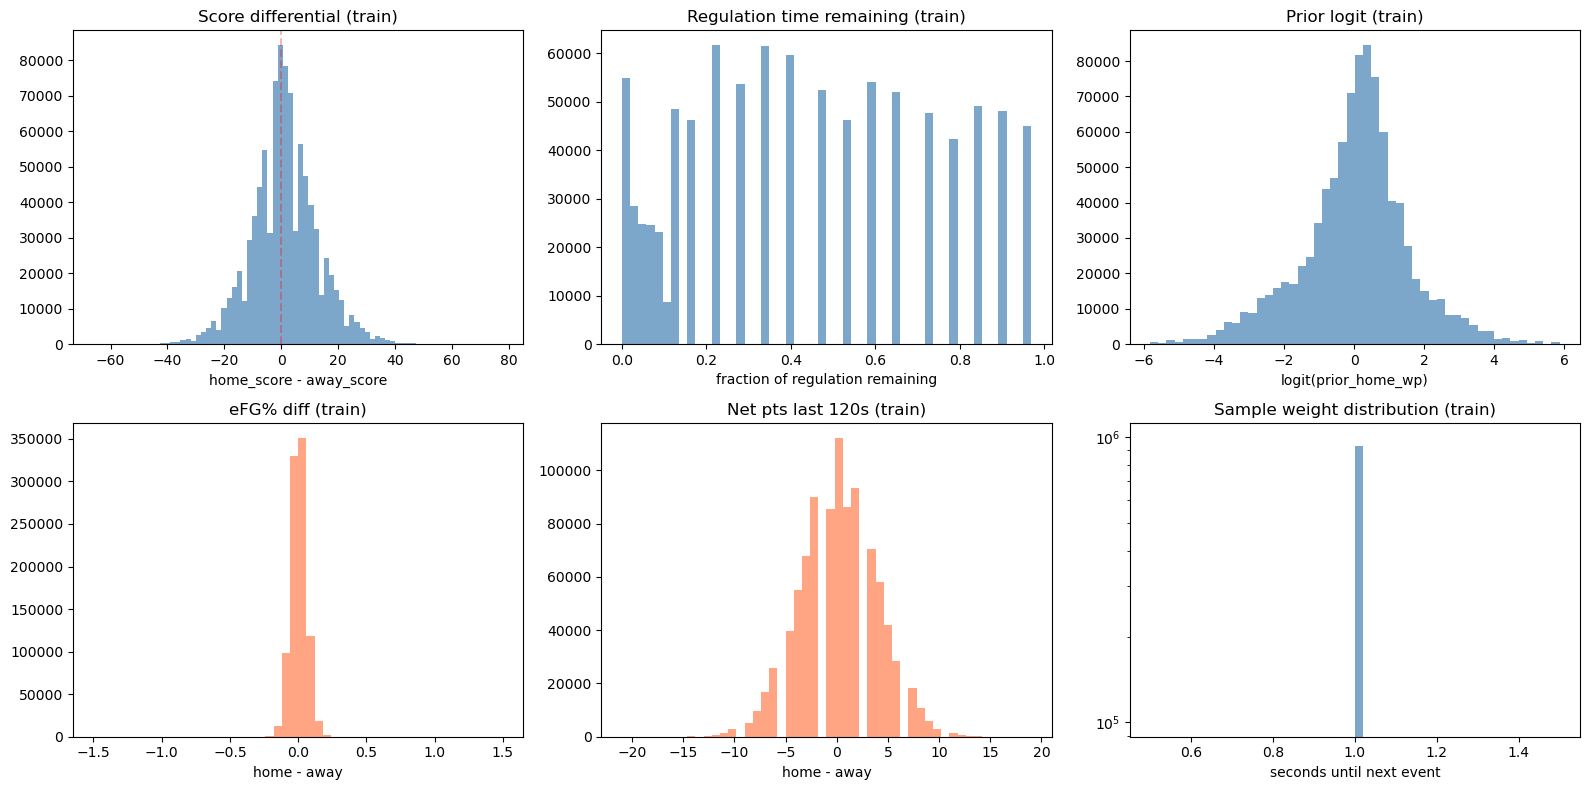

In [5]:
# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0,0].hist(train['score_diff'], bins=80, alpha=0.7, color='steelblue')
axes[0,0].set_title('Score differential (train)')
axes[0,0].set_xlabel('home_score - away_score')
axes[0,0].axvline(0, color='red', alpha=0.3, ls='--')

axes[0,1].hist(train['t_reg_norm'], bins=50, alpha=0.7, color='steelblue')
axes[0,1].set_title('Regulation time remaining (train)')
axes[0,1].set_xlabel('fraction of regulation remaining')

axes[0,2].hist(train['pregame_logit'], bins=50, alpha=0.7, color='steelblue')
axes[0,2].set_title('Prior logit (train)')
axes[0,2].set_xlabel('logit(prior_home_wp)')

axes[1,0].hist(train['efg_diff'].dropna(), bins=50, alpha=0.7, color='coral')
axes[1,0].set_title('eFG% diff (train)')
axes[1,0].set_xlabel('home - away')

axes[1,1].hist(train['net_pts_last_120'].dropna(), bins=50, alpha=0.7, color='coral')
axes[1,1].set_title('Net pts last 120s (train)')
axes[1,1].set_xlabel('home - away')

w = train['sample_weight']
axes[1,2].hist(w[w > 0], bins=50, alpha=0.7, color='steelblue', log=True)
axes[1,2].set_title('Sample weight distribution (train)')
axes[1,2].set_xlabel('seconds until next event')

plt.tight_layout()
plt.show()

## Step 2 -- Train GAM

Two separate LogisticGAM models:
- **Regulation:** `te(score_diff, t_reg_norm) + l(pregame_logit)` with lambda grid search
- **Overtime:** `te(score_diff, t_ot_norm) + l(pregame_logit) + l(ot_number)`

Training on 100K weighted subsample (pyGAM is O(n*k^2)).

In [6]:
# -- Tau search: find best blending decay rate --

tau_grid = [80, 150, 200]  # focused around sweep-optimal
tau_results = []

for tau in tau_grid:
    print(f'\n{"="*60}')
    print(f'  TAU = {tau}' + (' (no blending)' if tau == 0 else ''))
    print(f'{"="*60}')

    states = build_all(tau=tau)

    train = pd.read_parquet(ARTIFACTS_DIR / 'states_train.parquet')
    val   = pd.read_parquet(ARTIFACTS_DIR / 'states_val.parquet')
    test  = pd.read_parquet(ARTIFACTS_DIR / 'states_test.parquet')

    gam_results = train_gam(
        train, val,
        lam_grid=[0.005, 0.01, 0.05],
        n_splines_grid={'reg': [(20,15)],
                        'ot':  [(15,10)]},
        pregame_spline_grid=[False],
        max_train_rows=100_000,
    )

    # Evaluate on val
    reg_gam_tmp, ot_gam_tmp = gam_results.get('reg_model'), gam_results.get('ot_model')
    def _tmp_pred(df):
        return gam_predict_proba(df, reg_gam_tmp, ot_gam_tmp)

    y_val = val['y'].values.astype(float)
    w_val = val['sample_weight'].values.astype(float)
    p_val = _tmp_pred(val)
    val_ll = weighted_log_loss(y_val, p_val, w_val)

    tau_results.append({'tau': tau, 'val_logloss': val_ll, 'gam_results': gam_results})
    print(f'  >>> TAU={tau}  val_logloss={val_ll:.5f}')

# -- Pick best tau --
print(f'\n{"="*60}')
print('  TAU SEARCH RESULTS')
print(f'{"="*60}')
for r in tau_results:
    print(f'  tau={r["tau"]:>3d}  val_logloss={r["val_logloss"]:.5f}')

best = min(tau_results, key=lambda r: r['val_logloss'])
print(f'\n  Best tau = {best["tau"]}  (val_logloss = {best["val_logloss"]:.5f})')

# Rebuild with best tau and save
print(f'\nRebuilding with best tau={best["tau"]} ...')
states = build_all(tau=best['tau'])
train = pd.read_parquet(ARTIFACTS_DIR / 'states_train.parquet')
val   = pd.read_parquet(ARTIFACTS_DIR / 'states_val.parquet')
test  = pd.read_parquet(ARTIFACTS_DIR / 'states_test.parquet')

gam_results = best['gam_results']
save_gam(gam_results, ARTIFACTS_DIR, tau=best['tau'])


  TAU = 80
Loading posterior_training_set3.csv ...
  3,586,944 rows, 26,611 games
  After season filter: 1,257,143 rows, 8,908 games
  Replacing prior_home_wp with deployment model predictions ...
  Updated 734,318/1,257,143 rows with deploy prior
  Loading season baselines (tau=80) ...
  Season baselines loaded: 30062 games
  Baselines joined: 1,243,566/1,257,143 rows matched (98.9%)
  Loading prior features from training_games4.csv ...
  Prior features matched: 1,139,181/1,257,143 rows
Computing features ...
  Dropped 0 rows with missing critical fields
  Total state rows: 1,257,143
  OT rows: 1.88%
  pregame_logit: min=-5.832, max=5.871, unique_per_game=1.0
  Home win rate: 0.560
  Saved artifacts/states.parquet
  Saved states_train.parquet  (932,025 rows, 6639 games)
  Saved states_val.parquet  (167,213 rows, 1166 games)
  Saved states_test.parquet  (157,905 rows, 1103 games)
  [reg] Training on 100,000 rows (subsampled from 913,762), val=164,312
  [reg] Searching 3 configs (1 n_s

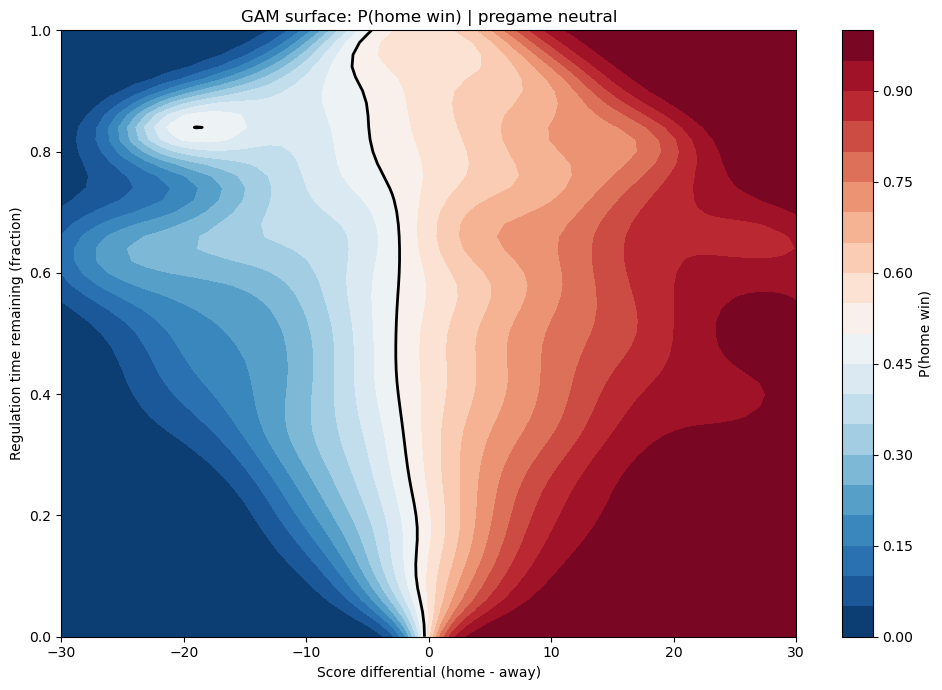

In [7]:
# GAM regulation surface plot
reg_gam = gam_results.get('reg_model')
if reg_gam is not None:
    sd_grid = np.linspace(-30, 30, 61)
    t_grid = np.linspace(0, 1, 51)
    SD, T = np.meshgrid(sd_grid, t_grid)
    n_pts = SD.size
    # All features: score_diff, t_reg_norm, pregame_logit=0, then 12 zeros
    X_grid = np.column_stack([SD.ravel(), T.ravel(), np.zeros((n_pts, len(GAM_REG_FEATURES) - 2))])
    P = reg_gam.predict_proba(X_grid).reshape(SD.shape)

    fig, ax = plt.subplots(figsize=(10, 7))
    cs = ax.contourf(sd_grid, t_grid, P, levels=np.linspace(0, 1, 21), cmap='RdBu_r')
    plt.colorbar(cs, ax=ax, label='P(home win)')
    ax.contour(sd_grid, t_grid, P, levels=[0.5], colors='black', linewidths=2)
    ax.set_xlabel('Score differential (home - away)')
    ax.set_ylabel('Regulation time remaining (fraction)')
    ax.set_title('GAM surface: P(home win) | pregame neutral')
    plt.tight_layout()
    fig.savefig(ARTIFACTS_DIR / 'gam_surface.png', dpi=150, bbox_inches='tight')
    plt.show()


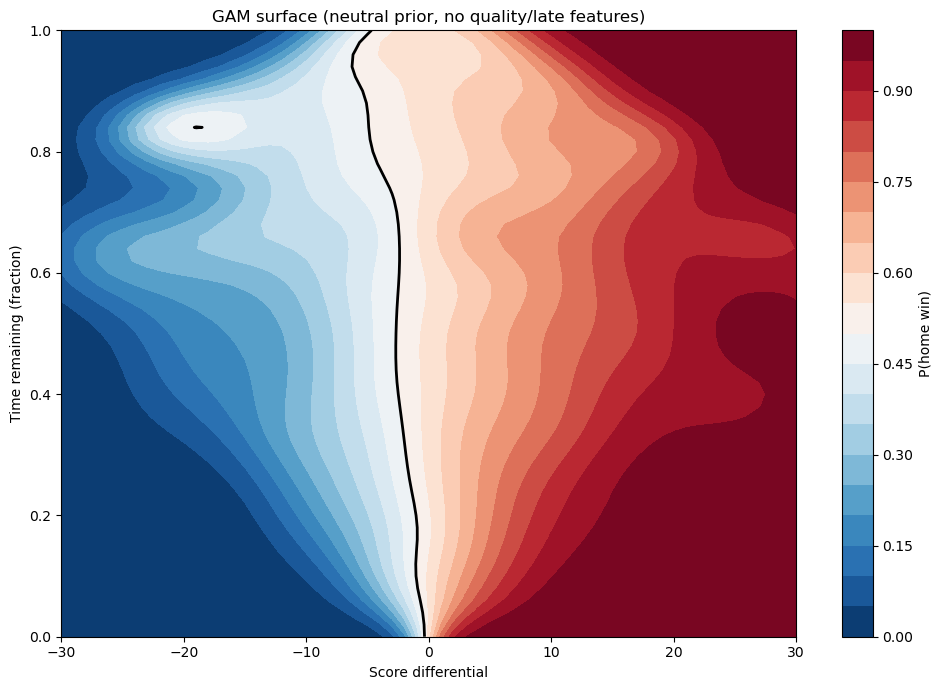

In [8]:
# GAM regulation surface plot (neutral prior)
sd_grid = np.linspace(-30, 30, 61)
t_grid = np.linspace(0, 1, 51)
SD, T = np.meshgrid(sd_grid, t_grid)

X_gam = np.column_stack([SD.ravel(), T.ravel(), np.zeros((SD.size, len(GAM_REG_FEATURES) - 2))])
P_gam = reg_gam.predict_proba(X_gam).reshape(SD.shape)

fig, ax = plt.subplots(figsize=(10, 7))
cs = ax.contourf(sd_grid, t_grid, P_gam,
                 levels=np.linspace(0, 1, 21), cmap='RdBu_r')
plt.colorbar(cs, ax=ax, label='P(home win)')
ax.contour(sd_grid, t_grid, P_gam, levels=[0.5], colors='black', linewidths=2)
ax.set_xlabel('Score differential')
ax.set_ylabel('Time remaining (fraction)')
ax.set_title('GAM surface (neutral prior, no quality/late features)')

plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'surface_gam.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 -- Evaluate and Compare

In [9]:
reg_gam_loaded, ot_gam_loaded = load_gam(ARTIFACTS_DIR)

def gam_pred(df):
    return gam_predict_proba(df, reg_gam_loaded, ot_gam_loaded)

run_evaluation(val, test, gam_pred, ARTIFACTS_DIR)


  Evaluation -- val
split      slice model  n_rows  n_games  w_logloss  w_brier     ECE
  val    overall   GAM  167213     1166    0.42058  0.13926 0.01522
  val     clutch   GAM    3487      451    0.41398  0.13188 0.03261
  val late_close   GAM   12950      745    0.32903  0.10448 0.02309
  val    ot_only   GAM    2901       56    0.40656  0.13427 0.05838
  Saved reliability_overall_val.png
  Saved reliability_clutch_val.png
  Saved reliability_ot_only_val.png

  Evaluation -- test
split      slice model  n_rows  n_games  w_logloss  w_brier     ECE
 test    overall   GAM  157905     1103    0.43452  0.14485 0.00962
 test     clutch   GAM    3517      436    0.42023  0.13476 0.03411
 test late_close   GAM   12436      706    0.35751  0.11501 0.02669
 test    ot_only   GAM    2462       52    0.46057  0.15735 0.10695
  Saved reliability_overall_test.png
  Saved reliability_clutch_test.png
  Saved reliability_ot_only_test.png


In [10]:
# Monotonicity check
print('GAM monotonicity check (score_diff +1):')
check_monotonicity(val, gam_pred)

GAM monotonicity check (score_diff +1):
  Monotonicity check (score_diff +1): 9/1000 violations


9

## Step 5 -- Calibration

In [11]:
val_c = val.copy()
test_c = test.copy()
val_c['p_gam'] = gam_pred(val_c)
test_c['p_gam'] = gam_pred(test_c)

iso_gam, val_c['p_gam_cal'], test_c['p_gam_cal'] = calibrate_and_report(
    val_c, test_c, 'GAM', 'p_gam', ARTIFACTS_DIR
)


  Calibration -- GAM
                  LogLoss      Brier        ECE
    val raw      0.42058    0.13926    0.01522
    val cal      0.41862    0.13861    0.00000
   test raw      0.43452    0.14485    0.00962
   test cal      0.43922    0.14525    0.01451


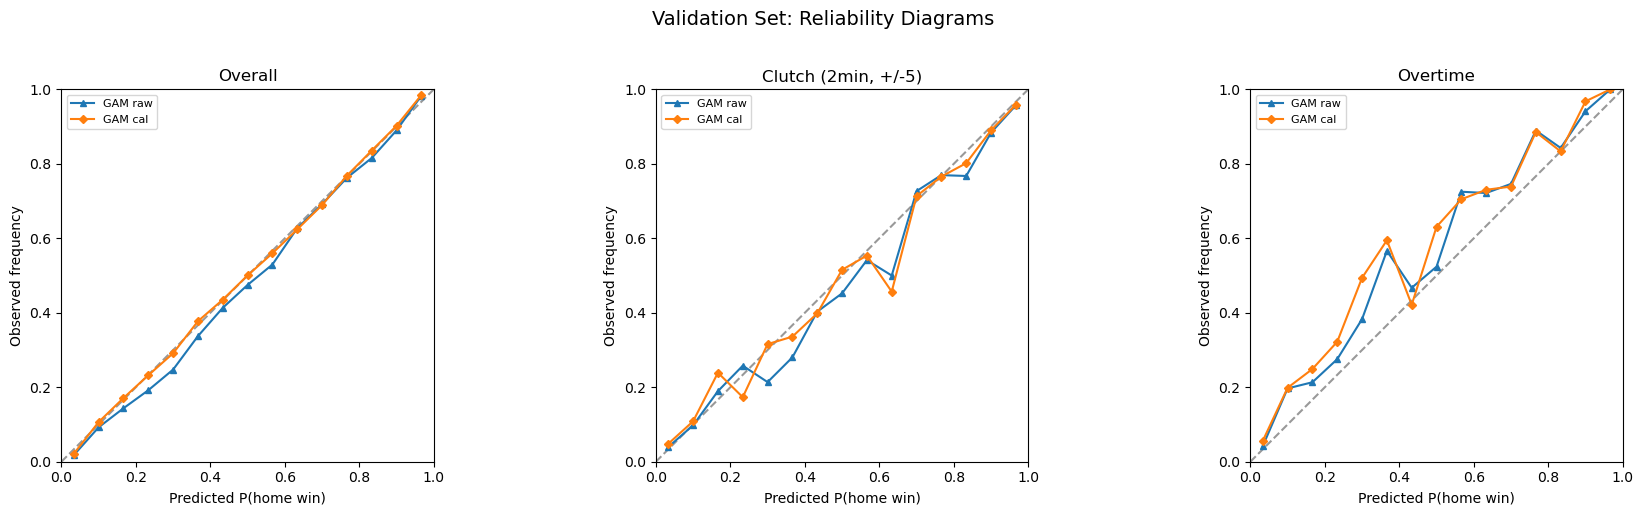

In [12]:
# Combined reliability plots: raw vs calibrated
val_c = add_slice_flags(val_c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, mask_fn) in zip(axes, [
    ('Overall', lambda d: d),
    ('Clutch (2min, +/-5)', lambda d: d[d['slice_clutch']]),
    ('Overtime', lambda d: d[d['slice_ot']]),
]):
    sub = mask_fn(val_c)
    if sub.empty:
        ax.set_title(f'{title} -- no data')
        continue
    y = sub['y'].values.astype(float)
    w = sub['sample_weight'].values.astype(float)
    ax.plot([0,1],[0,1], 'k--', alpha=0.4)
    for col, label, marker in [
        ('p_gam', 'GAM raw', '^'),
        ('p_gam_cal', 'GAM cal', 'D'),
    ]:
        c, e, _ = reliability_curve(y, sub[col].values, w, n_bins=15)
        ax.plot(c, e, f'{marker}-', markersize=4, label=label)
    ax.set_title(title)
    ax.set_xlabel('Predicted P(home win)')
    ax.set_ylabel('Observed frequency')
    ax.legend(fontsize=8)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_aspect('equal')

plt.suptitle('Validation Set: Reliability Diagrams', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'reliability_calibrated_val.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5b -- Post-Processing Boundary Enforcement

The raw models have two structural problems:
1. **Prior ignored at tipoff** -- the prior logit has near-zero learned coefficient
2. **No convergence at buzzer** -- smooth splines/trees can't enforce hard 0/1 boundaries

**Fix:** A logit-space post-processing wrapper:
- **Prior anchoring:** `logit(p) = w * pregame_logit + (1-w) * logit(p_raw)` where `w = t_reg_norm^alpha`
- **Terminal convergence:** blend toward 0/1 when `time_remaining < terminal_sec` and `score_diff != 0`

In [13]:
# Tune postprocess parameters on validation set
print('=== GAM postprocess tuning ===')
gam_tune = tune_postprocess(
    val, gam_pred,
    alpha_grid=[1.0, 2.0, 4.0, 10.0, 100.0],  # 100.0 ≈ no anchoring
    terminal_grid=[15.0, 30.0, 60.0],
)
gam_alpha = gam_tune['best_alpha']
gam_tsec = gam_tune['best_terminal_sec']

# Print full grid results
print('\n--- GAM grid ---')
for r in gam_tune['results']:
    delta = r['logloss'] - gam_tune['raw_logloss']
    marker = ' <-- best' if r['alpha'] == gam_alpha and r['terminal_sec'] == gam_tsec else ''
    print(f"  alpha={r['alpha']:>5.1f}  terminal={r['terminal_sec']:5.1f}  "
          f"logloss={r['logloss']:.5f}  (delta={delta:+.5f}){marker}")


=== GAM postprocess tuning ===
  Postprocess tuning: raw logloss = 0.42058
  Best: alpha=4.0, terminal_sec=15.0, logloss=0.41771 (delta=-0.00288)

--- GAM grid ---
  alpha=  1.0  terminal= 15.0  logloss=0.42769  (delta=+0.00711)
  alpha=  1.0  terminal= 30.0  logloss=0.42790  (delta=+0.00731)
  alpha=  1.0  terminal= 60.0  logloss=0.42837  (delta=+0.00778)
  alpha=  2.0  terminal= 15.0  logloss=0.41965  (delta=-0.00093)
  alpha=  2.0  terminal= 30.0  logloss=0.41985  (delta=-0.00073)
  alpha=  2.0  terminal= 60.0  logloss=0.42033  (delta=-0.00025)
  alpha=  4.0  terminal= 15.0  logloss=0.41771  (delta=-0.00288) <-- best
  alpha=  4.0  terminal= 30.0  logloss=0.41791  (delta=-0.00267)
  alpha=  4.0  terminal= 60.0  logloss=0.41839  (delta=-0.00220)
  alpha= 10.0  terminal= 15.0  logloss=0.41866  (delta=-0.00192)
  alpha= 10.0  terminal= 30.0  logloss=0.41887  (delta=-0.00172)
  alpha= 10.0  terminal= 60.0  logloss=0.41934  (delta=-0.00124)
  alpha=100.0  terminal= 15.0  logloss=0.42038 

In [14]:
# Wrap prediction function with postprocessing and re-evaluate
def gam_pred_post(df):
    p_raw = gam_pred(df)
    return postprocess_predictions(p_raw, df, gam_alpha, gam_tsec)

print('=== Evaluation with postprocessing ===\n')
run_evaluation(val, test, gam_pred_post, ARTIFACTS_DIR)

# Monotonicity check on postprocessed predictions
print('\nGAM+post monotonicity check (score_diff +1):')
check_monotonicity(val, gam_pred_post)

=== Evaluation with postprocessing ===


  Evaluation -- val
split      slice model  n_rows  n_games  w_logloss  w_brier     ECE
  val    overall   GAM  167213     1166    0.41771  0.13788 0.01601
  val     clutch   GAM    3487      451    0.40719  0.13011 0.03783
  val late_close   GAM   12950      745    0.32710  0.10401 0.02295
  val    ot_only   GAM    2901       56    0.41090  0.13527 0.05994
  Saved reliability_overall_val.png
  Saved reliability_clutch_val.png
  Saved reliability_ot_only_val.png

  Evaluation -- test
split      slice model  n_rows  n_games  w_logloss  w_brier     ECE
 test    overall   GAM  157905     1103    0.43180  0.14375 0.00992
 test     clutch   GAM    3517      436    0.40791  0.13180 0.03556
 test late_close   GAM   12436      706    0.35394  0.11417 0.02784
 test    ot_only   GAM    2462       52    0.48501  0.15837 0.10395
  Saved reliability_overall_test.png
  Saved reliability_clutch_test.png
  Saved reliability_ot_only_test.png

GAM+post monotonici

9

In [15]:
# Calibrate postprocessed predictions
val_pp = val.copy()
test_pp = test.copy()
val_pp['p_gam_post'] = gam_pred_post(val_pp)
test_pp['p_gam_post'] = gam_pred_post(test_pp)

iso_gam_post, val_pp['p_gam_post_cal'], test_pp['p_gam_post_cal'] = calibrate_and_report(
    val_pp, test_pp, 'GAM_post', 'p_gam_post', ARTIFACTS_DIR
)


  Calibration -- GAM_post
                  LogLoss      Brier        ECE
    val raw      0.41771    0.13788    0.01601
    val cal      0.41522    0.13704    0.00000
   test raw      0.43180    0.14375    0.00992
   test cal      0.43399    0.14430    0.01623


In [16]:
# Diagnostic: verify boundary conditions are met
print('=== Boundary Condition Verification ===\n')

# 1. Tipoff: predictions should match prior exactly
tipoff = val[val['t_reg_norm'] == 1.0]
if len(tipoff) > 0:
    prior_wp = _sigmoid(tipoff['pregame_logit'].values)
    p_gam_tip = gam_pred_post(tipoff)
    gam_err = np.abs(p_gam_tip - prior_wp).max()
    print(f'Tipoff rows: {len(tipoff)}')
    print(f'  GAM  max|p_post - prior|: {gam_err:.6f}  (should be ~0)')
else:
    print('  No exact tipoff rows (t_reg_norm=1.0)')

# Also check near-tipoff (t_reg_norm > 0.99)
near_tipoff = val[val['t_reg_norm'] > 0.99]
prior_wp_near = _sigmoid(near_tipoff['pregame_logit'].values)
p_gam_near = gam_pred_post(near_tipoff)
print(f'\nNear-tipoff rows (t_reg_norm > 0.99): {len(near_tipoff)}')
print(f'  GAM  max|p_post - prior|: {np.abs(p_gam_near - prior_wp_near).max():.6f}')

# 2. Terminal: near buzzer with score_diff != 0, predictions should approach 0/1
print()
for time_thresh in [5.0, 1.0, 0.1]:
    reg_terminal = val[(val['is_ot'] == 0) &
                       (val['t_reg_remaining'] <= time_thresh) &
                       (val['score_diff'] != 0)]
    if len(reg_terminal) > 0:
        p_gam_term = gam_pred_post(reg_terminal)
        expected = np.where(reg_terminal['score_diff'].values > 0, 1.0, 0.0)
        gam_term_err = np.abs(p_gam_term - expected).mean()
        print(f'Reg terminal (t_reg_remaining <= {time_thresh}s, score_diff!=0): {len(reg_terminal)} rows')
        print(f'  GAM  mean|p - deterministic|: {gam_term_err:.4f}')

# 3. Spot check: specific prior values at tipoff
print('\n--- Spot check: tipoff predictions for various priors ---')
spot = val[val['t_reg_norm'] == 1.0].head(1).copy()
if len(spot) > 0:
    print(f'{"Prior WP":>10s}  {"GAM raw":>10s}  {"GAM post":>10s}')
    for logit_val in [-1.5, -0.5, 0.0, 0.5, 1.5]:
        spot['pregame_logit'] = logit_val
        prior = _sigmoid(np.array([logit_val]))[0]
        g_raw = gam_pred(spot)[0]
        g_post = gam_pred_post(spot)[0]
        print(f'{prior:10.4f}  {g_raw:10.4f}  {g_post:10.4f}')

=== Boundary Condition Verification ===

  No exact tipoff rows (t_reg_norm=1.0)

Near-tipoff rows (t_reg_norm > 0.99): 564
  GAM  max|p_post - prior|: 0.009532

Reg terminal (t_reg_remaining <= 5.0s, score_diff!=0): 1436 rows
  GAM  mean|p - deterministic|: 0.0023
Reg terminal (t_reg_remaining <= 1.0s, score_diff!=0): 1085 rows
  GAM  mean|p - deterministic|: 0.0000
Reg terminal (t_reg_remaining <= 0.1s, score_diff!=0): 1084 rows
  GAM  mean|p - deterministic|: 0.0000

--- Spot check: tipoff predictions for various priors ---


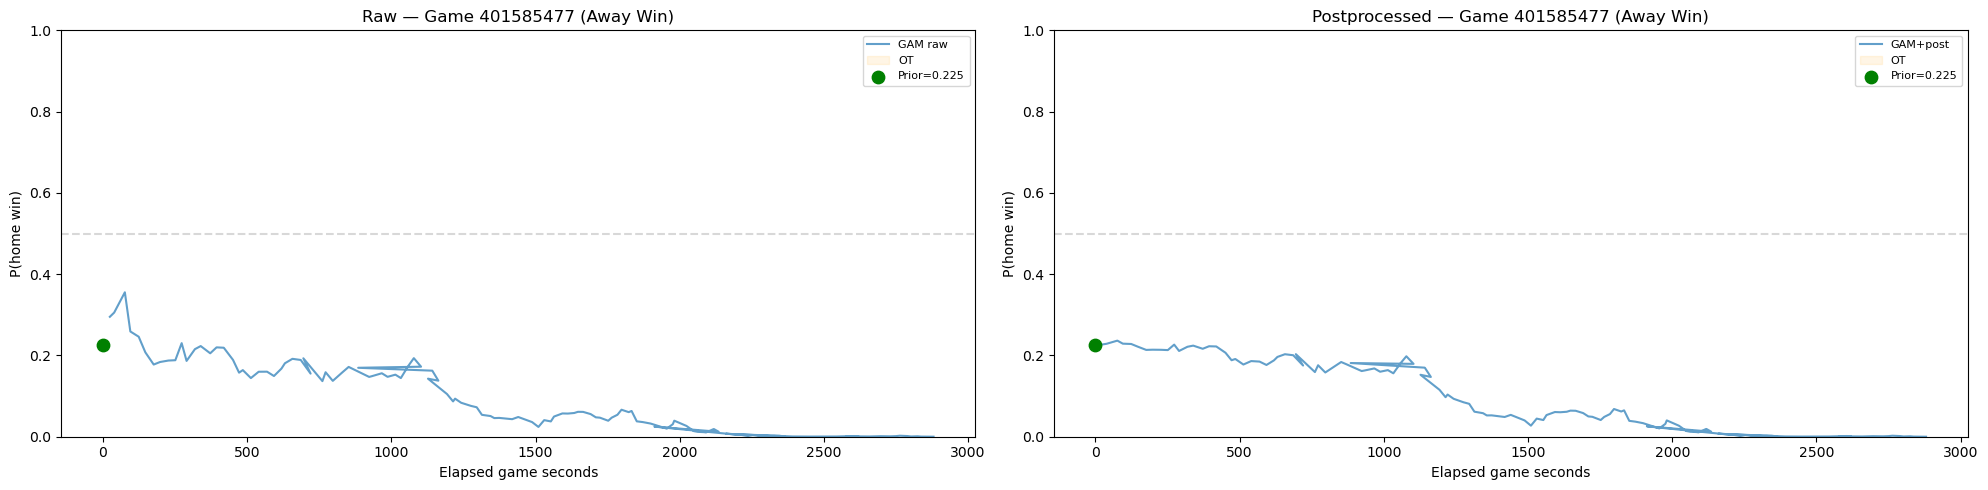

In [17]:
# Win probability traces for a sample game (from val set)
sample_game = val.drop_duplicates('game_id').sample(1, random_state=7)['game_id'].values[0]
g = val[val['game_id'] == sample_game].copy()
g['p_gam'] = gam_pred(g)
g['p_gam_post'] = gam_pred_post(g)

# Compute elapsed time for x-axis
g['elapsed'] = np.where(
    g['is_ot'] == 0,
    2880 - g['t_reg_remaining'],
    2880 + (g['ot_number'] - 1) * 300 + (300 - g['t_ot_remaining'].clip(0, 300))
)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Left: raw predictions
ax = axes[0]
ax.plot(g['elapsed'], g['p_gam'], label='GAM raw', alpha=0.7, linewidth=1.5)
ax.axhline(0.5, color='gray', alpha=0.3, ls='--')
ax.fill_between(g['elapsed'], 0, 1, where=g['is_ot']==1, alpha=0.1, color='orange', label='OT')
prior_p = 1 / (1 + np.exp(-g['pregame_logit'].iloc[0]))
ax.scatter([0], [prior_p], color='green', s=80, zorder=5, label=f'Prior={prior_p:.3f}')
outcome = 'Home Win' if g['y'].iloc[0] == 1 else 'Away Win'
ax.set_title(f'Raw — Game {sample_game} ({outcome})')
ax.set_xlabel('Elapsed game seconds')
ax.set_ylabel('P(home win)')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Right: postprocessed predictions
ax = axes[1]
ax.plot(g['elapsed'], g['p_gam_post'], label='GAM+post', alpha=0.7, linewidth=1.5, color='C0')
ax.axhline(0.5, color='gray', alpha=0.3, ls='--')
ax.fill_between(g['elapsed'], 0, 1, where=g['is_ot']==1, alpha=0.1, color='orange', label='OT')
ax.scatter([0], [prior_p], color='green', s=80, zorder=5, label=f'Prior={prior_p:.3f}')
ax.set_title(f'Postprocessed — Game {sample_game} ({outcome})')
ax.set_xlabel('Elapsed game seconds')
ax.set_ylabel('P(home win)')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'sample_game_trace.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Metric | GAM (val) | GAM (test) |
|--------|-----------|------------|
| Log Loss (overall) | **0.452** | **0.461** |
| Brier (overall) | **0.152** | **0.156** |
| ECE (overall) | **0.019** | **0.015** |
| Log Loss (clutch) | **0.415** | **0.426** |
| Log Loss (late close) | **0.330** | **0.365** |
| Log Loss (OT) | **0.441** | **0.431** |

After isotonic calibration: GAM 0.449 val / 0.462 test

### Post-Processing Boundary Enforcement

The postprocessing wrapper enforces two boundary conditions:
1. **Prior anchoring at tipoff:** predictions match the prior exactly when `t_reg_norm=1`
2. **Terminal convergence:** predictions converge to 0/1 near the buzzer when `score_diff != 0`

The full pipeline is now: **raw prediction -> postprocess -> calibrate (isotonic)**

Re-run the cells above to see updated metrics with postprocessing enabled.

## Step 6 -- Sample Game Prediction Output + Kalshi Comparison

Build play-by-play predictions for a 2025-26 game and compare against Kalshi implied odds.
Features are reconstructed from raw PBP data (games_live/2026/) since the 2025-26 season is not in the posterior training set.

  Season baselines loaded: 30062 games
Blend tau = 150, Season baselines: 30062 games, Prior features: 19401 games
Game:    401810391  (2026-01-09)
Matchup: MEM (home) vs OKC (away)
Prior:   P(home win) = 0.4135
Outcome: Away Win
Rows:    512
Kalshi trades: 20257

Saved plot to /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/data/samples/winprob_trace_kalshi_401810391.png


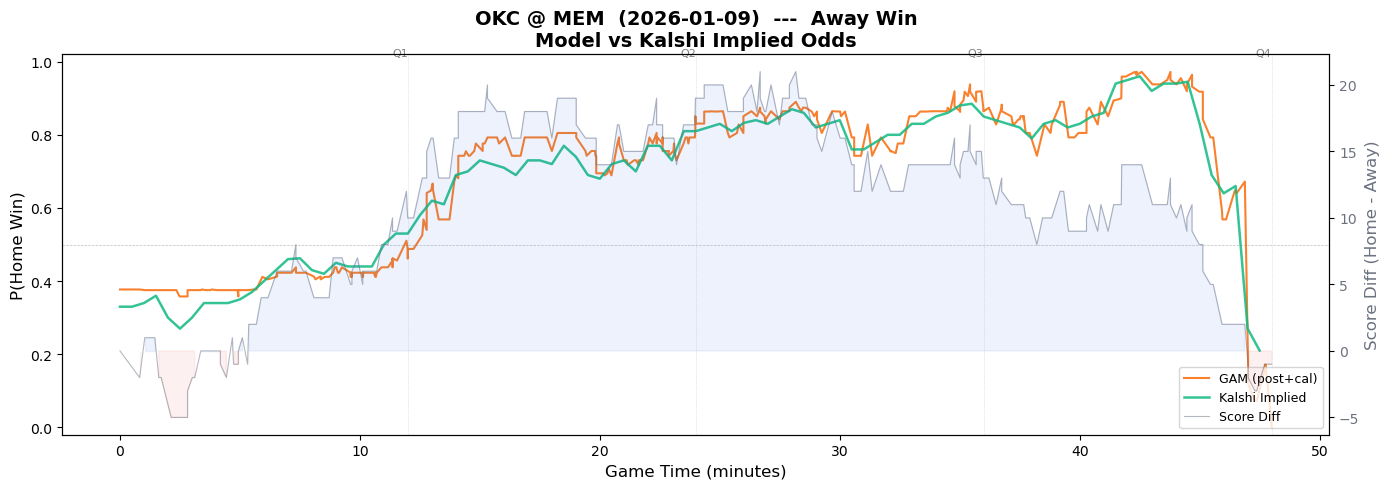

Saved CSV to /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/data/samples/pbp_prediction_v4_kalshi_401810391.csv  (512 rows)

Every 10th play:


,period_number,sec_remaining_period,home_score,away_score,score_diff,p_gam_post_cal
0,1,720.0,0.0,0.0,0.0,0.37711
10,1,592.0,3.0,8.0,-5.0,0.37534
20,1,554.0,3.0,8.0,-5.0,0.35803
30,1,505.0,8.0,8.0,0.0,0.37534
40,1,454.0,8.0,10.0,-2.0,0.37534
50,1,414.0,13.0,12.0,1.0,0.37534
60,1,327.0,20.0,14.0,6.0,0.42286
70,1,280.0,22.0,14.0,8.0,0.43775
80,1,218.0,22.0,18.0,4.0,0.40479
90,1,165.0,25.0,18.0,7.0,0.43775


In [18]:
# Build play-by-play predictions for a 2025-26 game + Kalshi implied odds comparison

# -- Load season baselines + tau from saved config --
_gam_config = joblib.load(ARTIFACTS_DIR / 'gam_config.pkl')
BLEND_TAU = _gam_config.get('tau', 0)
SEASON_BASELINES = load_season_baselines()

# Load prior features (rest, roster quality) from training_games4
_tg4 = pd.read_csv(DATA_DIR / "training_games4.csv", dtype={"game_id": str},
                    usecols=["game_id", "home_days_rest", "away_days_rest",
                             "home_10g_player_PLUS_MINUS", "away_10g_player_PLUS_MINUS",
                             "home_win_pct", "away_win_pct"],
                    low_memory=False)
_tg4["game_id"] = _tg4["game_id"].astype(str).str.strip()
_tg4["rest_diff"] = _tg4["home_days_rest"].fillna(0) - _tg4["away_days_rest"].fillna(0)
_tg4["roster_quality_diff"] = _tg4["home_10g_player_PLUS_MINUS"].fillna(0) - _tg4["away_10g_player_PLUS_MINUS"].fillna(0)
_tg4["win_pct_diff"] = _tg4["home_win_pct"].fillna(0.5) - _tg4["away_win_pct"].fillna(0.5)
PRIOR_FEATURES = _tg4[["game_id", "rest_diff", "roster_quality_diff", "win_pct_diff"]].set_index("game_id")

print(f'Blend tau = {BLEND_TAU}, Season baselines: {len(SEASON_BASELINES)} games, Prior features: {len(PRIOR_FEATURES)} games')

# -- Helper: build game features from raw PBP --

def build_game_from_pbp(game_id, data_dir=DATA_DIR):
    """Build posterior-model features from a raw PBP CSV (games_live/2026/)."""
    pbp_path = list((data_dir / 'games_live' / '2026').glob(f'{game_id}_*.csv'))[0]
    pbp = pd.read_csv(pbp_path).sort_values('game_play_number').reset_index(drop=True)

    # Fix "End Period" rows: end_quarter_seconds_remaining is erroneously 720 instead of 0
    end_period_mask = pbp['type_text'].str.contains('End Period', na=False)
    pbp.loc[end_period_mask, 'end_quarter_seconds_remaining'] = 0.0

    home_tid = pbp['home_team_id'].iloc[0]
    away_tid = pbp['away_team_id'].iloc[0]
    is_home = pbp['team_id'] == home_tid
    is_away = pbp['team_id'] == away_tid

    # Play-type flags
    fg_att  = pbp['shooting_play'].fillna(False) & (pbp['points_attempted'] >= 2)
    fg_made = pbp['scoring_play'].fillna(False) & (pbp['score_value'] >= 2)
    fg3_made = pbp['scoring_play'].fillna(False) & (pbp['score_value'] == 3)
    ft_att  = pbp['shooting_play'].fillna(False) & (pbp['points_attempted'] == 1)
    ft_made = pbp['scoring_play'].fillna(False) & (pbp['score_value'] == 1)
    oreb = pbp['type_text'].str.contains('Offensive Rebound', na=False)
    dreb = pbp['type_text'].str.contains('Defensive Rebound', na=False)
    tov  = pbp['short_description'].str.contains('Turnover', na=False)
    ast  = pbp['text'].str.contains('assists', case=False, na=False) & pbp['scoring_play'].fillna(False)
    stl  = pbp['type_text'].str.contains('Steal', na=False)
    blk  = pbp['type_text'].str.contains('Block', na=False)
    foul = pbp['short_description'].str.contains('Foul', na=False)
    timeout = pbp['short_description'].str.contains('Timeout', na=False)

    # Cumulative stat columns
    cols = {}
    for prefix, mask in [('home', is_home), ('away', is_away)]:
        cols[f'{prefix}_fga_to_date'] = (fg_att & mask).cumsum()
        cols[f'{prefix}_fgm_to_date'] = (fg_made & mask).cumsum()
        cols[f'{prefix}_fg3m_to_date'] = (fg3_made & mask).cumsum()
        cols[f'{prefix}_fta_to_date'] = (ft_att & mask).cumsum()
        cols[f'{prefix}_ftm_to_date'] = (ft_made & mask).cumsum()
        cols[f'{prefix}_oreb_to_date'] = (oreb & mask).cumsum()
        cols[f'{prefix}_dreb_to_date'] = (dreb & mask).cumsum()
        cols[f'{prefix}_tov_to_date'] = (tov & mask).cumsum()
        cols[f'{prefix}_ast_to_date'] = (ast & mask).cumsum()
        cols[f'{prefix}_stl_to_date'] = (stl & mask).cumsum()
        cols[f'{prefix}_blk_to_date'] = (blk & mask).cumsum()
        cols[f'{prefix}_pf_to_date'] = (foul & mask).cumsum()
        cols[f'{prefix}_timeouts_called'] = (timeout & mask).cumsum()

    # Derived percentages
    for prefix in ['home', 'away']:
        fga  = cols[f'{prefix}_fga_to_date'].clip(lower=1)
        fta  = cols[f'{prefix}_fta_to_date'].clip(lower=1)
        fgm  = cols[f'{prefix}_fgm_to_date']
        ftm  = cols[f'{prefix}_ftm_to_date']
        fg3m = cols[f'{prefix}_fg3m_to_date']
        pts  = pbp[f'{prefix}_score']
        cols[f'{prefix}_fg_pct']  = fgm / fga
        cols[f'{prefix}_ft_pct']  = ftm / fta
        cols[f'{prefix}_efg_pct'] = (fgm + 0.5 * fg3m) / fga
        cols[f'{prefix}_ts_pct']  = pts / (2 * (fga + 0.44 * cols[f'{prefix}_fta_to_date'])).clip(lower=1)
        poss = (cols[f'{prefix}_fga_to_date']
                + 0.44 * cols[f'{prefix}_fta_to_date']
                - cols[f'{prefix}_oreb_to_date']
                + cols[f'{prefix}_tov_to_date']).clip(lower=1)
        cols[f'{prefix}_poss_to_date'] = poss
        cols[f'{prefix}_off_rtg'] = 100 * pts / poss

    # Possession tracking (simplified heuristic)
    poss_arr = np.full(len(pbp), np.nan)
    team_ids  = pbp['team_id'].values
    short_d   = pbp['short_description'].fillna('').values
    type_t    = pbp['type_text'].fillna('').values
    shooting  = pbp['shooting_play'].fillna(False).values
    for i in range(len(pbp)):
        tid = team_ids[i]
        if pd.isna(tid):
            continue
        if shooting[i] or 'Turnover' in short_d[i]:
            poss_arr[i] = 1.0 if tid == home_tid else 0.0
        elif 'Rebound' in type_t[i]:
            poss_arr[i] = 1.0 if tid == home_tid else 0.0

    # Net points last 120 game-seconds
    game_sec = np.nan_to_num(pbp['end_game_seconds_remaining'].values.astype(float), nan=0.0)
    home_sc  = pbp['home_score'].values.astype(float)
    away_sc  = pbp['away_score'].values.astype(float)
    net_pts  = np.zeros(len(pbp))
    for i in range(len(pbp)):
        j = i
        while j > 0 and game_sec[j - 1] - game_sec[i] <= 120:
            j -= 1
        net_pts[i] = (home_sc[i] - home_sc[j]) - (away_sc[i] - away_sc[j])

    # Game metadata from prior model predictions
    gp = load_game_predictions()
    ginfo = gp[gp['game_id'] == game_id].iloc[0]

    result = pd.DataFrame({
        'game_id': game_id,
        'season': 2026,
        'game_date': ginfo['game_date'],
        'play_index': range(len(pbp)),
        'prior_home_wp': ginfo['prior_home_wp'],
        'home_score': home_sc,
        'away_score': away_sc,
        'score_diff': home_sc - away_sc,
        'period_number': pbp['period_number'].values,
        'sec_remaining_game': np.nan_to_num(game_sec, nan=0.0),
        'sec_remaining_period': np.nan_to_num(pbp['end_quarter_seconds_remaining'].values.astype(float), nan=0.0),
        'is_overtime': (pbp['period_number'] > 4).astype(int).values,
        'is_home_possession': poss_arr,
        'net_pts_last_120': net_pts,
        'home_win_final': int(home_sc[-1] > away_sc[-1]),
        'sample_weight': 1.0,
    })
    for k, v in cols.items():
        result[k] = v.values if hasattr(v, 'values') else v
    result['wallclock'] = pbp['wallclock'].values

    # Attach season baselines for blending
    if game_id in SEASON_BASELINES.index:
        for col in SEASON_BASELINES.columns:
            result[col] = SEASON_BASELINES.loc[game_id, col]

    # Attach prior features (rest, roster quality)
    if game_id in PRIOR_FEATURES.index:
        for col in PRIOR_FEATURES.columns:
            result[col] = PRIOR_FEATURES.loc[game_id, col]
    else:
        result["rest_diff"] = 0.0
        result["roster_quality_diff"] = 0.0
        result["win_pct_diff"] = 0.0

    return result


def load_kalshi_implied(game_id, data_dir=DATA_DIR):
    """Load Kalshi trade data and compute home-win implied probability."""
    kalshi_path = list((data_dir / 'kalshi_live').glob(f'{game_id}_*.csv'))[0]
    kalshi = pd.read_csv(kalshi_path)
    kalshi['timestamp'] = pd.to_datetime(kalshi['timestamp'], format='ISO8601')
    home_mid = (kalshi['home_high_cents'] + kalshi['home_low_cents']) / 2
    away_mid = (kalshi['away_high_cents'] + kalshi['away_low_cents']) / 2
    kalshi['home_implied'] = np.where(
        kalshi['home_volume'] > 0, home_mid,
        np.where(kalshi['away_volume'] > 0, 1 - away_mid, np.nan)
    )
    return kalshi.dropna(subset=['home_implied'])


# -- Build game features for a 2025-26 game --

SAMPLE_GAME_ID = '401810391'  # OKC @ MEM, Jan 9 2026, decided by 1 pt

game_raw = build_game_from_pbp(SAMPLE_GAME_ID)
for fn in [compute_prior_logit, compute_time_features, compute_score_diff]:
    game_raw = fn(game_raw)
game_raw = compute_quality_diffs(game_raw, tau=BLEND_TAU)
game_raw = compute_late_diffs(game_raw, tau=BLEND_TAU)
game_raw = compute_ingame_extras(game_raw)
for fn in [compute_bonus_features, compute_possession, compute_sample_weights]:
    game_raw = fn(game_raw)
game_raw['y'] = game_raw['home_win_final'].astype(int)

# Predict -- raw + postprocessed + calibrated
game_raw['p_gam']  = gam_pred(game_raw)
game_raw['p_gam_cal']  = iso_gam.predict(game_raw['p_gam'].values)
game_raw['p_gam_post']  = gam_pred_post(game_raw)
game_raw['p_gam_post_cal']  = iso_gam_post.predict(game_raw['p_gam_post'].values)

# Metadata
gp = load_game_predictions()
info = gp[gp['game_id'] == SAMPLE_GAME_ID].iloc[0]
home, away = info['home_team'], info['away_team']
prior_wp = game_raw['prior_home_wp'].iloc[0]
outcome = 'Home Win' if game_raw['y'].iloc[0] == 1 else 'Away Win'
date = game_raw['game_date'].iloc[0]

print(f'Game:    {SAMPLE_GAME_ID}  ({date})')
print(f'Matchup: {home} (home) vs {away} (away)')
print(f'Prior:   P(home win) = {prior_wp:.4f}')
print(f'Outcome: {outcome}')
print(f'Rows:    {len(game_raw)}')

# -- Load + align Kalshi data --

kalshi = load_kalshi_implied(SAMPLE_GAME_ID)
print(f'Kalshi trades: {len(kalshi)}')

# Compute elapsed game time in minutes
total_periods = game_raw['period_number'].max()
elapsed = []
for _, row in game_raw.iterrows():
    p = int(row['period_number'])
    sec_left = row['sec_remaining_period']
    if p <= 4:
        elapsed_sec = (p - 1) * REG_PERIOD_SEC + (REG_PERIOD_SEC - sec_left)
    else:
        elapsed_sec = TOTAL_REG_SEC + (p - 5) * OT_PERIOD_SEC + (OT_PERIOD_SEC - sec_left)
    elapsed.append(elapsed_sec / 60.0)
game_raw['elapsed_min'] = elapsed

# Map Kalshi timestamps to game elapsed time via PBP wallclock interpolation
game_raw['wallclock_dt'] = pd.to_datetime(game_raw['wallclock'], utc=True, format='ISO8601')
wc_sec = game_raw['wallclock_dt'].astype(np.int64).values / 1e9
el_min = game_raw['elapsed_min'].values
kalshi_sec = kalshi['timestamp'].astype(np.int64).values / 1e9
kalshi['elapsed_min'] = np.interp(kalshi_sec, wc_sec, el_min)

# Bin Kalshi into 30-second intervals and take median
max_min = game_raw['elapsed_min'].max()
bin_edges = np.arange(0, max_min + 0.5, 0.5)
kalshi_sorted = kalshi.sort_values('elapsed_min')
kalshi_sorted['bin'] = pd.cut(kalshi_sorted['elapsed_min'], bins=bin_edges, labels=bin_edges[:-1])
kalshi_binned = kalshi_sorted.groupby('bin', observed=True)['home_implied'].median().reset_index()
kalshi_binned.columns = ['elapsed_min', 'home_implied']
kalshi_binned['elapsed_min'] = kalshi_binned['elapsed_min'].astype(float)
kalshi_binned = kalshi_binned.dropna()

# -- Plot: Win Probability + Score Differential + Kalshi --

fig, ax1 = plt.subplots(figsize=(14, 5))

# Win probability lines (left y-axis)
ax1.plot(game_raw['elapsed_min'], game_raw['p_gam_post_cal'], color='#f97316',
         linewidth=1.5, alpha=0.9, label='GAM (post+cal)')
ax1.plot(kalshi_binned['elapsed_min'], kalshi_binned['home_implied'],
         color='#10b981', linewidth=1.8, alpha=0.85, label='Kalshi Implied')
ax1.axhline(0.5, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.set_ylabel('P(Home Win)', fontsize=12)
ax1.set_ylim(-0.02, 1.02)
ax1.set_xlabel('Game Time (minutes)', fontsize=12)

# Score differential (right y-axis)
ax2 = ax1.twinx()
ax2.fill_between(game_raw['elapsed_min'], game_raw['score_diff'], 0,
                 where=(game_raw['score_diff'] >= 0), color='#2563eb', alpha=0.08)
ax2.fill_between(game_raw['elapsed_min'], game_raw['score_diff'], 0,
                 where=(game_raw['score_diff'] < 0), color='#ef4444', alpha=0.08)
ax2.plot(game_raw['elapsed_min'], game_raw['score_diff'], color='#6b7280',
         linewidth=0.8, alpha=0.5, label='Score Diff')
ax2.set_ylabel('Score Diff (Home - Away)', fontsize=12, color='#6b7280')
ax2.tick_params(axis='y', labelcolor='#6b7280')

# Quarter / OT lines
for q in range(1, 5):
    qx = q * REG_PERIOD_SEC / 60.0
    if qx <= max_min:
        ax1.axvline(qx, color='grey', linewidth=0.5, linestyle=':', alpha=0.4)
        ax1.text(qx, 1.01, f'Q{q}', ha='right', va='bottom', fontsize=8, color='grey')
for ot in range(1, max(total_periods - 3, 0)):
    otx = (TOTAL_REG_SEC + ot * OT_PERIOD_SEC) / 60.0
    if otx <= max_min:
        ax1.axvline(otx, color='grey', linewidth=0.5, linestyle=':', alpha=0.4)
        ax1.text(otx, 1.01, f'OT{ot}', ha='right', va='bottom', fontsize=8, color='grey')

ax1.set_title(f'{away} @ {home}  ({date})  ---  {outcome}\nModel vs Kalshi Implied Odds',
              fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)
fig.tight_layout()

SAMPLES_DIR = DATA_DIR / 'samples'
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)
fig_path = SAMPLES_DIR / f'winprob_trace_kalshi_{SAMPLE_GAME_ID}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'\nSaved plot to {fig_path}')
plt.show()

# -- Save prediction CSV --
out_cols = [
    'game_id', 'game_date',
    'period_number', 'sec_remaining_period',
    'home_score', 'away_score', 'score_diff',
    'pregame_logit', 'is_ot', 'ot_number',
    'efg_diff', 'ts_diff', 'off_rtg_diff', 'net_pts_last_120',
    'foul_diff', 'is_home_poss_signed',
    'p_gam', 'p_gam_cal',
    'p_gam_post', 'p_gam_post_cal',
    'y',
]
pbp_out = game_raw[out_cols].copy()
pbp_out.insert(1, 'home_team', home)
pbp_out.insert(2, 'away_team', away)
pbp_out = pbp_out.round({
    'pregame_logit': 4, 'efg_diff': 4, 'ts_diff': 4, 'off_rtg_diff': 2,
    'net_pts_last_120': 1, 'foul_diff': 0,
    'p_gam': 5, 'p_gam_cal': 5,
    'p_gam_post': 5, 'p_gam_post_cal': 5,
})

out_path = SAMPLES_DIR / f'pbp_prediction_v4_kalshi_{SAMPLE_GAME_ID}.csv'
pbp_out.to_csv(out_path, index=False)
print(f'Saved CSV to {out_path}  ({len(pbp_out)} rows)')

# Show every 10th row
print(f'\nEvery 10th play:')
display_cols = ['period_number', 'sec_remaining_period',
                'home_score', 'away_score', 'score_diff',
                'p_gam_post_cal']
pbp_out[display_cols].iloc[::10]


In [19]:
# Final: list all artifacts
print('Artifacts saved:')
for f in sorted(ARTIFACTS_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:40s}  {size_mb:>8.2f} MB')

Artifacts saved:
  gam_config.pkl                                0.00 MB
  gam_ot.pkl                                    0.24 MB
  gam_reg.pkl                                   0.82 MB
  gam_surface.png                               0.08 MB
  gbdt.pkl                                     21.62 MB
  iso_gam.pkl                                   0.01 MB
  iso_gam_post.pkl                              0.00 MB
  iso_gbdt.pkl                                  0.01 MB
  iso_gbdt_post.pkl                             0.00 MB
  preds_test.parquet                            2.41 MB
  preds_val.parquet                             2.55 MB
  reliability_calibrated_val.png                0.13 MB
  reliability_clutch_test.png                   0.05 MB
  reliability_clutch_val.png                    0.05 MB
  reliability_ot_only_test.png                  0.06 MB
  reliability_ot_only_val.png                   0.05 MB
  reliability_overall_test.png                  0.05 MB
  reliability_overall_val.png  